In [170]:
"""
Statistical Analysis — Single Agent vs Multi-Agent Comparison
==============================================================
Comprehensive analysis notebook. Loads both single-agent results from 
portfolios_01/ and multi-agent results from portfolios/, then produces 
comparative statistics and visualizations for both.
"""
import json, re, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

from src.compute_benchmarks import run_benchmarks_standalone, compute_metrics as bm_compute_metrics
from data.wrds_data import WRDSDATA

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# ── Configuration ─────────────────────────────────────────────────────────
SINGLE_AGENT_DIR = Path("private_results/single_agent")   # single-agent JSONs (nested: timestamp/runN/portfolios/{persona}.json)
MULTI_AGENT_DIR = Path("private_results/multi_agent")       # multi-agent JSONs
INITIAL_CAPITAL = 1_000_000.0
PERIODS_PER_YEAR = 4  # quarterly
RF_ANNUAL = 0.02
BENCHMARK = "benchmarks.json"
cmap = plt.cm.get_cmap('tab10')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

# ── Experiment parameters
START_DATE = "2014-01-01"
END_DATE   = "2023-12-31"
FREQUENCY  = "quarterly"
N_STOCKS   = None          # None = all available stocks

print("Config loaded.")
print(f"Single-agent DIR: {SINGLE_AGENT_DIR.resolve()}")
print(f"Multi-agent DIR: {MULTI_AGENT_DIR.resolve()}")

Config loaded.
Single-agent DIR: /home/nbockholt_lm/ASIM-LLM-MAS/private_results/single_agent
Multi-agent DIR: /home/nbockholt_lm/ASIM-LLM-MAS/private_results/multi_agent


/tmp/ipykernel_4150187/826480880.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


In [171]:
#result = run_benchmarks_standalone(start_date="2014-01-01",end_date="2023-12-31",output_json="benchmarks.json")  # Saves results as JSON)

## 1. Load Portfolio Data

In [172]:
# ── Load benchmarks from JSON ──────────────────────────────────────────────
print("Loading benchmarks from JSON...")
with open(BENCHMARK) as f:
    benchmarks_raw = json.load(f)

# New format: benchmarks are nested under "benchmarks" key
# Structure: {"benchmarks": {"cap_weighted": {period: nav, ...}, ...}, "metrics": {...}, ...}
benchmarks = benchmarks_raw.get("benchmarks", {})
benchmarks = {"nasdaq100_index": benchmarks["nasdaq100_index"]}
print(f"Benchmarks loaded: {list(benchmarks.keys())}\n")

# ── Helper functions ──────────────────────────────────────────────────────
def quarterly_returns(navs):
    """Period-over-period returns from NAV array."""
    return navs[1:] / navs[:-1] - 1.0

def compute_metrics(navs, ppy=PERIODS_PER_YEAR, rf=RF_ANNUAL):
    """Compute risk/return metrics from a NAV series."""
    rets = quarterly_returns(navs)
    n = len(rets)
    if n == 0:
        return {}
    rf_q = rf / ppy
    cum = np.prod(1 + rets)
    cagr = cum ** (ppy / n) - 1
    vol_q = float(np.std(rets, ddof=1)) if n > 1 else 0
    vol_ann = vol_q * np.sqrt(ppy)
    mean_excess = float(np.mean(rets)) - rf_q
    sharpe = (mean_excess / vol_q * np.sqrt(ppy)) if vol_q > 0 else 0
    downside = np.where(rets - rf_q < 0, rets - rf_q, 0)
    dd_dev = float(np.sqrt(np.mean(downside**2)))
    sortino = (mean_excess / dd_dev * np.sqrt(ppy)) if dd_dev > 0 else 0
    peak = np.maximum.accumulate(navs)
    max_dd = float(np.max((peak - navs) / peak))
    calmar = cagr / max_dd if max_dd > 0 else 0
    return {
        "total_return_pct": round((cum - 1) * 100, 2),
        "cagr_pct": round(cagr * 100, 2),
        "volatility_pct": round(vol_ann * 100, 2),
        "sharpe": round(sharpe, 3),
        "sortino": round(sortino, 3),
        "max_drawdown_pct": round(max_dd * 100, 2),
        "calmar": round(calmar, 3),
        "final_nav": round(navs[-1], 2),
        "n_periods": n,
    }

# ── Helper functions for portfolio loading ────────────────────────────────
def _extract_agent_run_from_filename(filename: str) -> tuple:
    """Extract agent name and run index from filename like 'agent_name_run123'."""
    m = re.match(r"(.+?)_run(\d+)$", filename)
    if m:
        return m.group(1), int(m.group(2))
    return filename, 1


def _extract_composition_metrics(snapshot: dict, agent_col_name: str, name: str, run_idx: int) -> dict:
    """Extract portfolio composition metrics from a single snapshot."""
    concentration = snapshot.get("concentration", {})
    return {
        agent_col_name: name,
        "run": run_idx,
        "period": snapshot.get("period"),
        "num_holdings": concentration.get("num_holdings"),
        "herfindahl_index": concentration.get("herfindahl_index"),
        "max_position_pct": concentration.get("max_position_pct"),
        "cash_pct": concentration.get("cash_pct"),
        "equity_allocated_pct": concentration.get("equity_allocated_pct"),
    }


def _extract_metrics_row(pdata: dict, agent_col_name: str, name: str, run_idx: int, filepath) -> dict:
    """Extract performance metrics from portfolio JSON data."""
    stored = pdata.get("metrics", {})
    return {
        agent_col_name: name,
        "run": run_idx,
        "file": filepath.name,
        "total_return_pct": stored.get("total_return_pct"),
        "cagr_pct": stored.get("annualized_return_pct"),
        "volatility_pct": stored.get("annualized_volatility_pct"),
        "sharpe": stored.get("sharpe_ratio"),
        "sortino": stored.get("sortino_ratio"),
        "max_drawdown_pct": stored.get("max_drawdown_pct"),
        "final_nav": stored.get("final_portfolio_value"),
        "n_periods": stored.get("n_periods"),
    }


def _recompute_missing_metrics(df_metrics: pd.DataFrame, all_nav_series: dict, agent_col_name: str) -> None:
    """Recompute missing performance metrics from NAV data in-place."""
    for idx, row in df_metrics.iterrows():
        if pd.isna(row.get("sharpe")):
            agent_name = row[agent_col_name]
            run_idx = int(row["run"])
            if agent_name in all_nav_series and run_idx in all_nav_series[agent_name]:
                navs = all_nav_series[agent_name][run_idx][1]
                recomp = compute_metrics(navs)
                for k, v in recomp.items():
                    df_metrics.at[idx, k] = v


def load_portfolio_data(portfolio_dir, agent_col_name="agent"):
    """Load portfolios from a directory and return nav_series, metrics, and composition metrics.
    
    Args:
        portfolio_dir: Path to directory containing portfolio JSON files
        agent_col_name: Column name for the agent/strategy identifier
        
    Returns:
        Tuple of (all_nav_series dict, df_metrics DataFrame, df_composition DataFrame)
    """
    portfolio_dir = Path(portfolio_dir)
    if not portfolio_dir.exists():
        raise FileNotFoundError(f"Portfolio directory not found: {portfolio_dir}")
    
    portfolio_files = sorted(portfolio_dir.glob("**/*.json"))
    if not portfolio_files:
        raise ValueError(f"No portfolio files found in {portfolio_dir}")
    
    print(f"Found {len(portfolio_files)} portfolio file(s):\n")

    all_nav_series = {}
    all_metrics = []
    all_composition = []

    for fp in portfolio_files:
        try:
            with open(fp) as f:
                pdata = json.load(f)
        except (json.JSONDecodeError, IOError) as e:
            print(f"  Warning: Failed to load {fp.name}: {e}")
            continue

        name, run_idx = _extract_agent_run_from_filename(fp.stem)
        
        snapshots = pdata.get("snapshots", [])
        if not snapshots:
            print(f"  Warning: No snapshots in {fp.name}")
            continue
            
        periods = [s["period"] for s in snapshots]
        navs = np.array([s["nav"] for s in snapshots])

        if name not in all_nav_series:
            all_nav_series[name] = {}
        
        all_nav_series[name][run_idx] = (periods, navs)
        
        # Extract composition metrics per period
        for snapshot in snapshots:
            all_composition.append(_extract_composition_metrics(snapshot, agent_col_name, name, run_idx))
        
        # Extract metrics
        all_metrics.append(_extract_metrics_row(pdata, agent_col_name, name, run_idx, fp))
        print(f"  {fp.name:30s}  {agent_col_name}={name:20s}  run={run_idx}  periods={len(snapshots)}")

    # Build metrics DataFrame and recompute missing values
    df_metrics = pd.DataFrame(all_metrics)
    _recompute_missing_metrics(df_metrics, all_nav_series, agent_col_name)

    return all_nav_series, df_metrics, pd.DataFrame(all_composition)

Loading benchmarks from JSON...
Benchmarks loaded: ['nasdaq100_index']



In [173]:
def load_portfolio_data_from_private_results(base_dir="private_results", agent_col_name="strategy"):
    """Load portfolios from nested structure in private_results/multi_agent/.
    
    Directory structure:
      private_results/multi_agent/
        ├── avg_size_runs/multi_agent_TIMESTAMP/run1-N/portfolios/average_size.json
        ├── llm_manager_runs/multi_agent_TIMESTAMP/run1-N/portfolios/llm_manager.json
        └── majority_vote_runs/multi_agent_TIMESTAMP/run1-N/portfolios/majority_vote.json
    
    Dynamically discovers run directories and renumbers them sequentially (1 to N) per strategy.
    
    Args:
        base_dir: Path to private_results/multi_agent directory
        agent_col_name: Column name for the strategy identifier
        
    Returns:
        Tuple of (all_nav_series dict, df_metrics DataFrame, df_composition DataFrame)
        
    Raises:
        FileNotFoundError: If base_dir does not exist
    """
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f"Base directory not found: {base_path}")
    
    # Map strategy folder names to their file names
    STRATEGY_MAPPING = {
        "avg_size_runs": "average_size.json",
        "llm_manager_runs": "llm_manager.json",
        "majority_vote_runs": "majority_vote.json",
    }
    
    all_nav_series = {}
    all_metrics = []
    all_composition = []
    file_count = 0
    
    # Process each strategy
    for strategy_folder, portfolio_filename in STRATEGY_MAPPING.items():
        strategy_path = base_path / strategy_folder
        
        if not strategy_path.exists():
            print(f"  Strategy folder not found: {strategy_path}")
            continue
        
        # Extract strategy name (remove '_runs' suffix)
        strategy_name = strategy_folder.replace("_runs", "")
        
        # Find all timestamp directories
        timestamp_dirs = sorted([d for d in strategy_path.iterdir() if d.is_dir()])
        
        # Track sequential run number for this strategy
        sequential_run_num = 0
        
        for timestamp_dir in timestamp_dirs:
            # Discover all run directories dynamically
            try:
                run_dirs = sorted([d for d in timestamp_dir.iterdir() 
                                 if d.is_dir() and d.name.startswith("run")])
            except OSError as e:
                print(f"  Warning: Could not read {timestamp_dir}: {e}")
                continue
            
            for run_dir in run_dirs:
                portfolio_file = run_dir / "portfolios" / portfolio_filename
                
                if not portfolio_file.exists():
                    continue
                
                try:
                    with open(portfolio_file) as f:
                        pdata = json.load(f)
                except (json.JSONDecodeError, IOError) as e:
                    print(f"  Warning: Failed to load {portfolio_file.name}: {e}")
                    continue
                
                # Extract NAV data
                snapshots = pdata.get("snapshots", [])
                if not snapshots:
                    print(f"  Warning: No snapshots in {portfolio_file.name}")
                    continue
                
                sequential_run_num += 1
                periods = [s["period"] for s in snapshots]
                navs = np.array([s["nav"] for s in snapshots])
                
                # Store NAV series
                if strategy_name not in all_nav_series:
                    all_nav_series[strategy_name] = {}
                all_nav_series[strategy_name][sequential_run_num] = (periods, navs)
                
                # Extract composition and metrics for each snapshot
                for snapshot in snapshots:
                    all_composition.append(_extract_composition_metrics(
                        snapshot, agent_col_name, strategy_name, sequential_run_num
                    ))
                
                # Extract metrics
                all_metrics.append(_extract_metrics_row(pdata, agent_col_name, strategy_name, 
                                                       sequential_run_num, portfolio_file))
                
                file_count += 1
                print(f"  {portfolio_file.name:20s}  {agent_col_name}={strategy_name:20s}  "
                      f"run={sequential_run_num:2d}  timestamp={timestamp_dir.name:25s}  "
                      f"periods={len(snapshots)}")
    
    print(f"\nFound {file_count} portfolio file(s)\n")
    
    # Build metrics DataFrame and recompute missing values
    df_metrics = pd.DataFrame(all_metrics)
    _recompute_missing_metrics(df_metrics, all_nav_series, agent_col_name)
    
    # Build composition metrics DataFrame
    df_composition = pd.DataFrame(all_composition)
    
    return all_nav_series, df_metrics, df_composition

In [174]:
def load_single_agent_data_from_private_results(base_dir="private_results/single_agent",
                                                agent_col_name="agent",
                                                exclude_agents=None):
    """Load single-agent portfolios from nested structure in private_results/single_agent/.

    Directory structure:
      private_results/single_agent/
        ├── single_agent_TIMESTAMP_1/
        │     ├── run1/portfolios/ben_graham.json
        │     ├── run1/portfolios/buffett.json
        │     ├── run1/portfolios/cathie_wood.json
        │     ├── ...
        │     ├── run2/portfolios/{persona}.json
        │     └── ...
        ├── single_agent_TIMESTAMP_2/
        │     └── ...
        └── ...

    Each `runN/portfolios/` folder contains one JSON per agent persona, where the
    persona name is derived from the JSON filename (e.g. `ben_graham.json` -> `ben_graham`).

    Run numbers are renumbered sequentially per agent (1..N), aggregating across
    all timestamp directories — mirroring the multi-agent loader behaviour.

    Args:
        base_dir: Path to private_results/single_agent directory
        agent_col_name: Column name for the agent identifier
        exclude_agents: Optional iterable of agent names to skip (e.g. ["ben_graham"]).
            Matched against the JSON filename stem. Defaults to None (include all).

    Returns:
        Tuple of (all_nav_series dict, df_metrics DataFrame, df_composition DataFrame)

    Raises:
        FileNotFoundError: If base_dir does not exist
    """
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f"Base directory not found: {base_path}")

    # Normalize exclude list to a set for O(1) lookups
    excluded = set(exclude_agents) if exclude_agents else set()
    if excluded:
        print(f"Excluding agents: {sorted(excluded)}\n")

    all_nav_series = {}
    all_metrics = []
    all_composition = []
    file_count = 0
    skipped_count = 0

    # Per-agent sequential run counter (so runs are renumbered 1..N across timestamps)
    sequential_run_counter = {}

    # Discover all timestamp directories (e.g. single_agent_0423.1824.02)
    timestamp_dirs = sorted([d for d in base_path.iterdir() if d.is_dir()])

    if not timestamp_dirs:
        raise ValueError(f"No timestamp directories found in {base_path}")

    for timestamp_dir in timestamp_dirs:
        # Discover all run directories inside this timestamp folder
        try:
            run_dirs = sorted([d for d in timestamp_dir.iterdir()
                               if d.is_dir() and d.name.startswith("run")])
        except OSError as e:
            print(f"  Warning: Could not read {timestamp_dir}: {e}")
            continue

        for run_dir in run_dirs:
            portfolios_dir = run_dir / "portfolios"
            if not portfolios_dir.exists():
                continue

            # Each JSON in portfolios/ is one agent persona
            portfolio_files = sorted(portfolios_dir.glob("*.json"))
            for portfolio_file in portfolio_files:
                # Agent name is the filename stem (e.g. ben_graham.json -> ben_graham)
                agent_name = portfolio_file.stem

                # Skip excluded agents BEFORE loading the JSON (saves I/O)
                if agent_name in excluded:
                    skipped_count += 1
                    continue

                try:
                    with open(portfolio_file) as f:
                        pdata = json.load(f)
                except (json.JSONDecodeError, IOError) as e:
                    print(f"  Warning: Failed to load {portfolio_file.name}: {e}")
                    continue

                # Extract NAV data
                snapshots = pdata.get("snapshots", [])
                if not snapshots:
                    print(f"  Warning: No snapshots in {portfolio_file.name}")
                    continue

                # Sequential run number per agent
                sequential_run_counter[agent_name] = sequential_run_counter.get(agent_name, 0) + 1
                sequential_run_num = sequential_run_counter[agent_name]

                periods = [s["period"] for s in snapshots]
                navs = np.array([s["nav"] for s in snapshots])

                # Store NAV series
                if agent_name not in all_nav_series:
                    all_nav_series[agent_name] = {}
                all_nav_series[agent_name][sequential_run_num] = (periods, navs)

                # Extract composition metrics for each snapshot
                for snapshot in snapshots:
                    all_composition.append(_extract_composition_metrics(
                        snapshot, agent_col_name, agent_name, sequential_run_num
                    ))

                # Extract performance metrics
                all_metrics.append(_extract_metrics_row(pdata, agent_col_name, agent_name,
                                                       sequential_run_num, portfolio_file))

                file_count += 1
                print(f"  {portfolio_file.name:25s}  {agent_col_name}={agent_name:20s}  "
                      f"run={sequential_run_num:2d}  timestamp={timestamp_dir.name:25s}  "
                      f"periods={len(snapshots)}")

    print(f"\nFound {file_count} portfolio file(s)" +
          (f" (skipped {skipped_count} from excluded agents)" if skipped_count else "") +
          "\n")

    # Build metrics DataFrame and recompute missing values
    df_metrics = pd.DataFrame(all_metrics)
    _recompute_missing_metrics(df_metrics, all_nav_series, agent_col_name)

    # Build composition metrics DataFrame
    df_composition = pd.DataFrame(all_composition)

    return all_nav_series, df_metrics, df_composition

[single_agent] extracted 150 file(s) across 5 agent(s) -> extracted/single_agent
    ben_graham                  30 run(s)
    buffett                     30 run(s)
    cathie_wood                 30 run(s)
    joel_greenblatt             30 run(s)
    ray_dalio                   30 run(s)
[multi_agent] extracted 90 file(s) across 3 agent(s) -> extracted/multi_agent
    avg_size                    30 run(s)
    llm_manager                 30 run(s)
    majority_vote               30 run(s)


{'avg_size': 30, 'llm_manager': 30, 'majority_vote': 30}

In [175]:
all_nav_series_single, df_metrics_single, df_composition_single = \
    load_single_agent_data_from_private_results(
        base_dir=SINGLE_AGENT_DIR,
        agent_col_name="agent",
    )

all_nav_series_multi, df_metrics_multi, df_composition_multi = \
    load_portfolio_data_from_private_results(base_dir=MULTI_AGENT_DIR, agent_col_name="strategy")

  ben_graham.json            agent=ben_graham            run= 1  timestamp=single_agent_0427.1520.35  periods=41
  buffett.json               agent=buffett               run= 1  timestamp=single_agent_0427.1520.35  periods=41
  cathie_wood.json           agent=cathie_wood           run= 1  timestamp=single_agent_0427.1520.35  periods=41
  joel_greenblatt.json       agent=joel_greenblatt       run= 1  timestamp=single_agent_0427.1520.35  periods=41
  ray_dalio.json             agent=ray_dalio             run= 1  timestamp=single_agent_0427.1520.35  periods=41
  ben_graham.json            agent=ben_graham            run= 2  timestamp=single_agent_0427.1520.35  periods=41
  buffett.json               agent=buffett               run= 2  timestamp=single_agent_0427.1520.35  periods=41
  cathie_wood.json           agent=cathie_wood           run= 2  timestamp=single_agent_0427.1520.35  periods=41
  joel_greenblatt.json       agent=joel_greenblatt       run= 2  timestamp=single_agent_0427.152

## 2. Data Summary


In [176]:
def print_summary_statistics(df_metrics_list, agent_col_names, titles, benchmarks_dict=None, ci_level=0.95):
    """Print summary statistics with 95% confidence intervals."""
    from scipy import stats as sp_stats
    
    for df_metrics, agent_col_name, title in zip(df_metrics_list, agent_col_names, titles):
        print("\n" + "=" * 100)
        print(f"{title} — Summary Statistics (95% CI)")
        print("=" * 100 + "\n")

        # Group by agent and compute stats
        for agent_name in sorted(df_metrics[agent_col_name].unique()):
            agent_data = df_metrics[df_metrics[agent_col_name] == agent_name]
            print(f"{agent_name}:")
            for metric in ["total_return_pct", "cagr_pct", "volatility_pct", "sharpe", "sortino", "max_drawdown_pct"]:
                values = agent_data[metric].dropna().values
                if len(values) > 0:
                    mean_val = np.mean(values)
                    se = sp_stats.sem(values)
                    ci = se * sp_stats.t.ppf((1 + ci_level) / 2, len(values) - 1)
                    print(f"  {metric:20s}: {mean_val:8.2f} ± {ci:6.2f}")
            print()
        
        # Add benchmarks for single-agent if provided
        if benchmarks_dict and agent_col_name == "agent":
            print("Benchmarks:")
            for bm_name, bm_series in benchmarks_dict.items():
                bm_navs = np.array(list(bm_series.values()))
                bm_metrics = compute_metrics(bm_navs)
                print(f"  {bm_name}:")
                for metric in ["total_return_pct", "cagr_pct", "volatility_pct", "sharpe", "sortino", "max_drawdown_pct"]:
                    if metric in bm_metrics:
                        print(f"    {metric:20s}: {bm_metrics[metric]:8.2f}")
                print()

In [177]:
# Display both dataframes
print("SINGLE-AGENT METRICS:")
print(df_metrics_single)
print("\n" + "=" * 80 + "\n")
print("MULTI-AGENT METRICS:")
print(df_metrics_multi)


SINGLE-AGENT METRICS:
               agent  run                  file total_return_pct cagr_pct  \
0         ben_graham    1       ben_graham.json          5790.89    50.32   
1            buffett    1          buffett.json            29.55     2.62   
2        cathie_wood    1      cathie_wood.json            28.01      2.5   
3    joel_greenblatt    1  joel_greenblatt.json           257.54    13.59   
4          ray_dalio    1        ray_dalio.json            11.59      1.1   
..               ...  ...                   ...              ...      ...   
145        ray_dalio   28        ray_dalio.json           437.54    18.32   
146  joel_greenblatt   29  joel_greenblatt.json          2118.51    36.33   
147        ray_dalio   29        ray_dalio.json           429.98    18.15   
148  joel_greenblatt   30  joel_greenblatt.json           980.02    26.87   
149        ray_dalio   30        ray_dalio.json           402.46    17.52   

    volatility_pct sharpe sortino max_drawdown_pct   

## 3. Summary Statistics

In [178]:
# ── Print summary statistics for both datasets ──────────────────────────
print_summary_statistics(
    [df_metrics_single, df_metrics_multi],
    ["agent", "strategy"],
    ["Single-Agent", "Multi-Agent"],
    benchmarks_dict=benchmarks,
    ci_level=0.95
)



Single-Agent — Summary Statistics (95% CI)

ben_graham:
  total_return_pct    :  5235.56 ± 911.78
  cagr_pct            :    47.17 ±   3.02
  volatility_pct      :    43.79 ±   2.06
  sharpe              :     1.09 ±   0.04
  sortino             :     2.30 ±   0.13
  max_drawdown_pct    :    53.67 ±   2.09

buffett:
  total_return_pct    :   298.33 ±  89.72
  cagr_pct            :    12.90 ±   2.72
  volatility_pct      :    30.89 ±   2.31
  sharpe              :     0.47 ±   0.07
  sortino             :     0.87 ±   0.16
  max_drawdown_pct    :    50.36 ±   4.16

cathie_wood:
  total_return_pct    :   133.07 ±  82.56
  cagr_pct            :     4.18 ±   5.13
  volatility_pct      :    31.17 ±   2.28
  sharpe              :     0.32 ±   0.08
  sortino             :     0.52 ±   0.17
  max_drawdown_pct    :    60.99 ±   7.17

joel_greenblatt:
  total_return_pct    :   862.52 ± 255.13
  cagr_pct            :    23.16 ±   2.97
  volatility_pct      :    32.54 ±   2.13
  sharpe           

## 4. NAV Equity Curves

In [179]:
def plot_nav_curves(nav_series_single, nav_series_multi, initial_capital, benchmark_series=None):
    """Plot NAV equity curves: single+benchmarks, multi-agent, and combined."""
    cmap = plt.cm.get_cmap('tab10')
    colors = [cmap(i) for i in np.linspace(0, 1, 10)]
    
    # Prepare single-agent with benchmarks
    single_dict = {**nav_series_single, **(benchmark_series or {})}
    
    # Create figures
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # ── Left: Single-Agent with Benchmarks ──
    ax = axes[0]
    agent_colors_1 = {name: colors[i % len(colors)] 
                      for i, name in enumerate(single_dict)}
    for agent_name, runs_dict in single_dict.items():
        is_bm = agent_name.startswith("BM:")
        color = agent_colors_1[agent_name]
        for i, (run_idx, (periods, navs)) in enumerate(runs_dict.items()):
            x = range(len(navs))
            ls = "--" if is_bm else "-"
            lw = 2.0 if is_bm else 1.5
            alpha = 1.0 if len(runs_dict) == 1 or is_bm else 0.5
            ax.plot(x, navs, ls, lw=lw, alpha=alpha, color=color,
                    label=agent_name if i == 0 else None)
    ax.axhline(initial_capital, color="gray", ls=":", lw=0.8, alpha=0.5)
    ax.set_title("Single-Agent (with Benchmarks)")
    ax.set_xlabel("Period")
    ax.set_ylabel("NAV ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    
    # ── Middle: Multi-Agent ──
    ax = axes[1]
    agent_colors_2 = {name: colors[i % len(colors)] 
                      for i, name in enumerate(nav_series_multi)}
    for agent_name, runs_dict in nav_series_multi.items():
        color = agent_colors_2[agent_name]
        for i, (run_idx, (periods, navs)) in enumerate(runs_dict.items()):
            x = range(len(navs))
            alpha = 1.0 if len(runs_dict) == 1 else 0.5
            ax.plot(x, navs, "-", lw=1.5, alpha=alpha, color=color,
                    label=agent_name if i == 0 else None)
    ax.axhline(initial_capital, color="gray", ls=":", lw=0.8, alpha=0.5)
    ax.set_title("Multi-Agent")
    ax.set_xlabel("Period")
    ax.set_ylabel("NAV ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    
    # ── Right: Combined (aggregate means) ──
    ax = axes[2]
    # Single-agent mean
    if nav_series_single:
        single_means = []
        for name, runs_dict in nav_series_single.items():
            all_navs = [navs for _, (_, navs) in runs_dict.items()]
            if all_navs:
                if len(all_navs) > 1:
                    single_means.append(np.mean(all_navs, axis=0))
                else:
                    single_means.append(all_navs[0])
        if single_means:
            single_mean_nav = np.mean(single_means, axis=0)
            ax.plot(range(len(single_mean_nav)), single_mean_nav, "-", lw=2.5, color=colors[0], 
                   label="Single-Agent Mean", alpha=0.9)
    
    # Multi-agent mean
    if nav_series_multi:
        multi_means = []
        for name, runs_dict in nav_series_multi.items():
            all_navs = [navs for _, (_, navs) in runs_dict.items()]
            if all_navs:
                if len(all_navs) > 1:
                    multi_means.append(np.mean(all_navs, axis=0))
                else:
                    multi_means.append(all_navs[0])
        if multi_means:
            multi_mean_nav = np.mean(multi_means, axis=0)
            ax.plot(range(len(multi_mean_nav)), multi_mean_nav, "-", lw=2.5, color=colors[1],
                   label="Multi-Agent Mean", alpha=0.9)
    
    # Benchmark means
    if benchmark_series:
        for name, runs_dict in benchmark_series.items():
            all_navs = [navs for _, (_, navs) in runs_dict.items()]
            if all_navs:
                bm_mean_nav = np.mean(all_navs, axis=0)
                ax.plot(range(len(bm_mean_nav)), bm_mean_nav, "--", lw=2.5, color=colors[2],
                       label=name, alpha=0.9)
    
    ax.axhline(initial_capital, color="gray", ls=":", lw=0.8, alpha=0.5)
    ax.set_title("Combined Comparison (Means)")
    ax.set_xlabel("Period")
    ax.set_ylabel("NAV ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4150187/2736942154.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


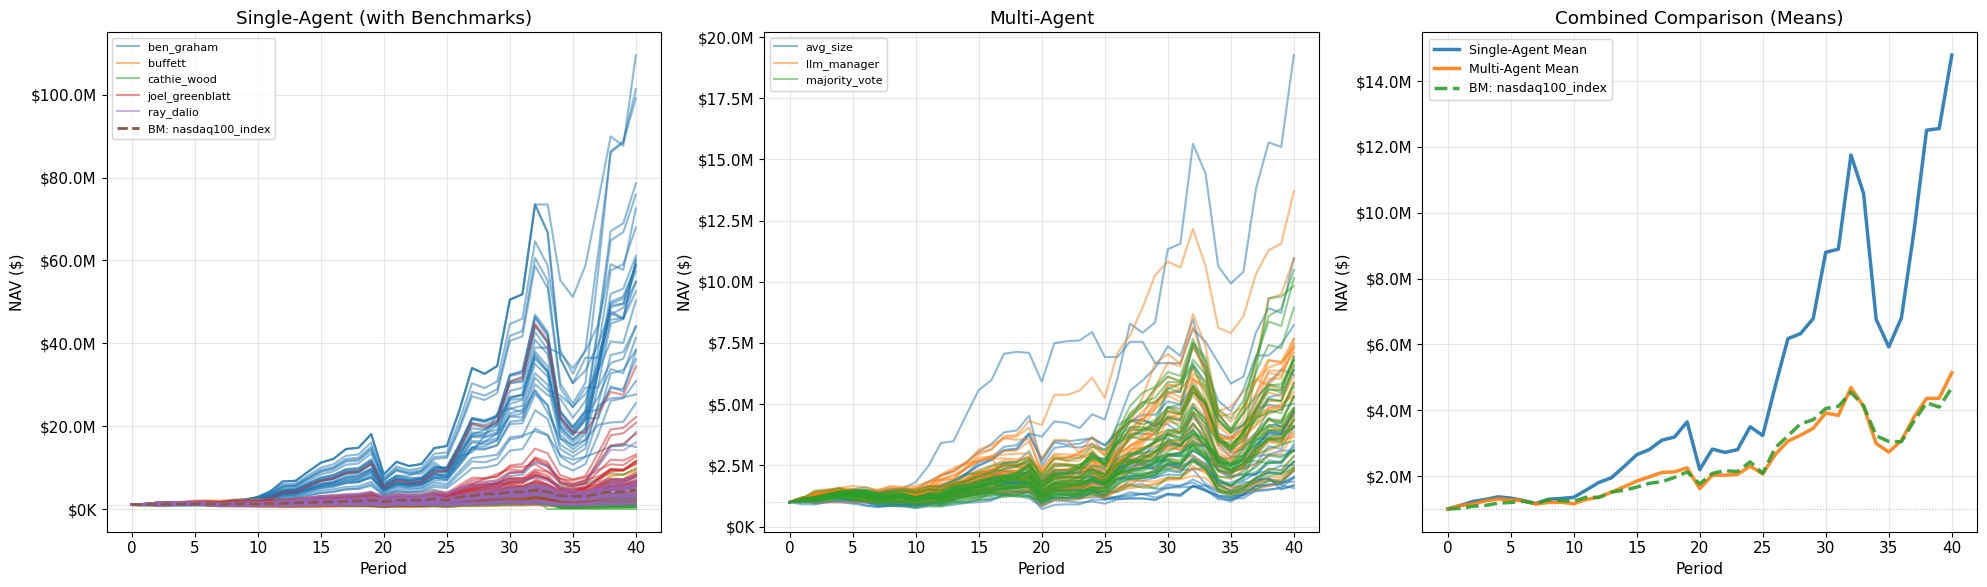

In [180]:
# ── Build benchmark NAV series and plot all datasets ──────────────────
benchmark_nav_series = {}
for bm_name, bm_series in benchmarks.items():
    bm_navs = np.array(list(bm_series.values()))
    benchmark_nav_series[f"BM: {bm_name}"] = {1: (list(bm_series.keys()), bm_navs)}

# Plot: single-agent with benchmarks, multi-agent, and combined comparison
plot_nav_curves(all_nav_series_single, all_nav_series_multi, INITIAL_CAPITAL, 
                benchmark_series=benchmark_nav_series)

## 5. CAGR Distribution

In [181]:
def plot_cagr_boxplots(df_metrics_list, agent_col_names, titles, benchmarks_dict=None):
    """Plot CAGR distribution as boxplots across datasets with combined comparison."""
    cmap = plt.cm.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 1, 10)]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # ── Left: Single-Agent CAGR ──
    ax = axes[0]
    if len(df_metrics_list) > 0:
        df_data = df_metrics_list[0]
        agent_col = agent_col_names[0]
        agents = sorted(df_data[agent_col].unique())
        cagr_data = [df_data[df_data[agent_col] == a]["cagr_pct"].values for a in agents]
        bp = ax.boxplot(cagr_data, labels=agents, patch_artist=True)
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
        ax.set_title(titles[0])
        ax.set_ylabel("CAGR (%)")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
    
    # ── Middle: Multi-Agent CAGR ──
    ax = axes[1]
    if len(df_metrics_list) > 1:
        df_data = df_metrics_list[1]
        agent_col = agent_col_names[1]
        agents = sorted(df_data[agent_col].unique())
        cagr_data = [df_data[df_data[agent_col] == a]["cagr_pct"].values for a in agents]
        bp = ax.boxplot(cagr_data, labels=agents, patch_artist=True)
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
        ax.set_title(titles[1])
        ax.set_ylabel("CAGR (%)")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
    
    # ── Right: Combined CAGR (all three types) ──
    ax = axes[2]
    all_cagrs = []
    all_labels = []
    
    # Single-agent
    if len(df_metrics_list) > 0:
        for cagr in df_metrics_list[0]["cagr_pct"].dropna().values:
            all_cagrs.append(cagr)
            all_labels.append("SA")
    
    # Multi-agent
    if len(df_metrics_list) > 1:
        for cagr in df_metrics_list[1]["cagr_pct"].dropna().values:
            all_cagrs.append(cagr)
            all_labels.append("MA")
    
    # Benchmarks
    if benchmarks_dict:
        for bm_name, bm_series in benchmarks_dict.items():
            bm_navs = np.array(list(bm_series.values()))
            bm_metrics = compute_metrics(bm_navs)
            all_cagrs.append(bm_metrics.get("cagr_pct", 0))
            all_labels.append(f"BM: {bm_name}")
    
    # Group by label type for visualization
    sa_cagrs = [all_cagrs[i] for i in range(len(all_cagrs)) if all_labels[i] == "SA"]
    ma_cagrs = [all_cagrs[i] for i in range(len(all_cagrs)) if all_labels[i] == "MA"]
    bm_cagrs = [all_cagrs[i] for i in range(len(all_cagrs)) if "BM:" in all_labels[i]]
    bm_names = [all_labels[i] for i in range(len(all_cagrs)) if "BM:" in all_labels[i]]
    
    combined_data = []
    combined_labels = []
    if sa_cagrs:
        combined_data.append(sa_cagrs)
        combined_labels.append("SA")
    if ma_cagrs:
        combined_data.append(ma_cagrs)
        combined_labels.append("MA")
    for i, bm_name in enumerate(bm_names):
        combined_data.append([bm_cagrs[i]])
        combined_labels.append(bm_name)
    
    if combined_data:
        bp = ax.boxplot(combined_data, labels=combined_labels, patch_artist=True)
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
        ax.set_title("Combined Comparison")
        ax.set_ylabel("CAGR (%)")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4150187/2241144534.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
/tmp/ipykernel_4150187/2241144534.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cagr_data, labels=agents, patch_artist=True)
/tmp/ipykernel_4150187/2241144534.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cagr_data, labels=agents, patch_artist=True)
/tmp/ipykernel_4150187/2241144534.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3

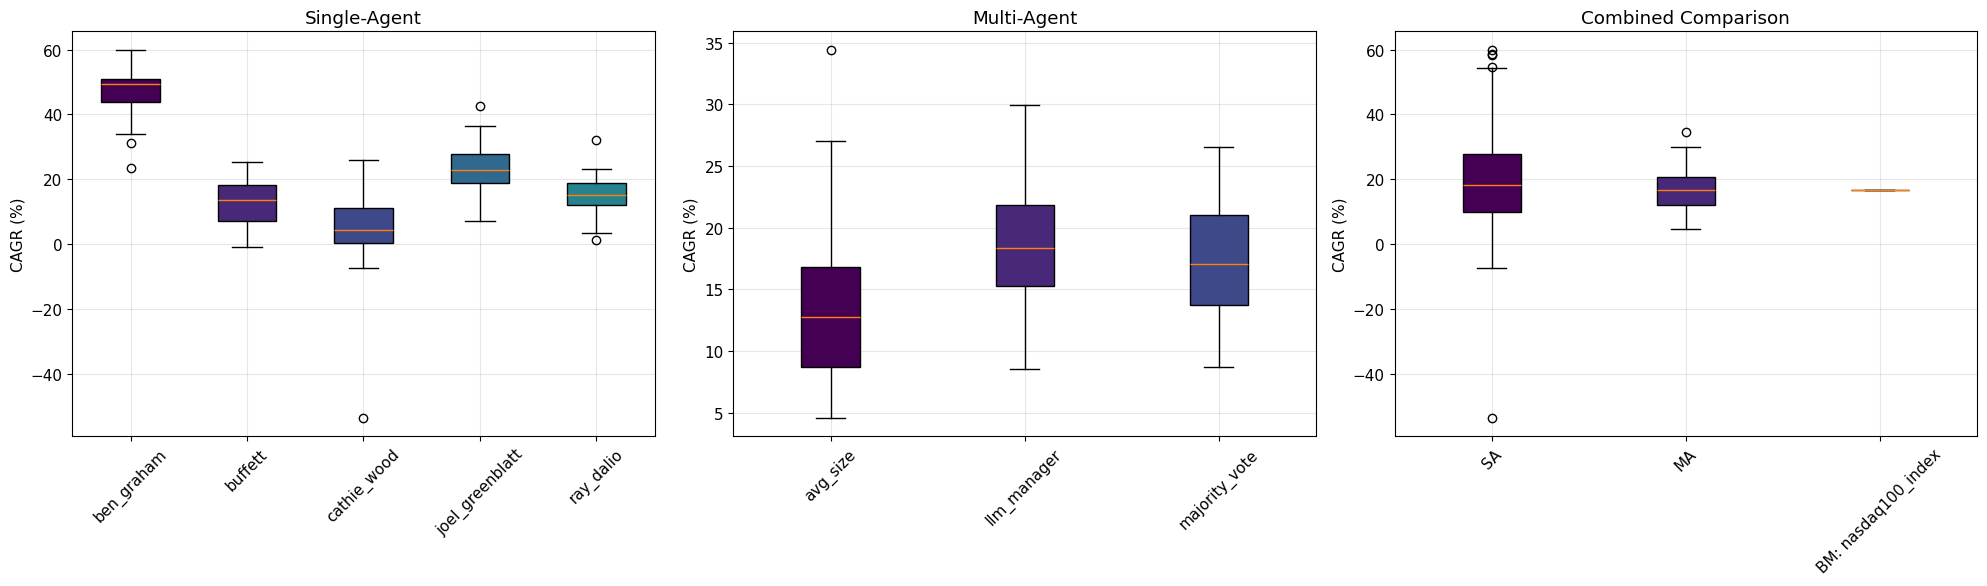

In [182]:
# ── Boxplot of CAGR distribution across datasets ──────────────────────────
plot_cagr_boxplots(
    [df_metrics_single, df_metrics_multi],
    ["agent", "strategy"],
    ["Single-Agent", "Multi-Agent"],
    benchmarks_dict=benchmarks
)


## 6. Return Distribution

In [183]:
def plot_return_distributions(nav_series_list, titles, benchmarks_dict=None):
    """Plot quarterly return distributions for all datasets as individual plots."""

    # ── Plot 1: Single-Agent ──
    if len(nav_series_list) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        all_returns = []
        for name, runs_dict in nav_series_list[0].items():
            for run_idx, (periods, navs) in runs_dict.items():
                all_returns.extend(quarterly_returns(navs))
        all_returns_pct = np.array(all_returns) * 100
        ax.hist(all_returns_pct, bins=30, alpha=0.7, color=colors[0], edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', linewidth=2, label='0%', alpha=0.7)
        ax.axvline(np.mean(all_returns_pct), color='green', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(all_returns_pct):.2f}%', alpha=0.7)
        ax.set_title(titles[0], fontsize=13, fontweight='bold')
        ax.set_xlabel("Quarterly Return (%)", fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    
    # ── Plot 2: Multi-Agent ──
    if len(nav_series_list) > 1:
        fig, ax = plt.subplots(figsize=(12, 6))
        all_returns = []
        for name, runs_dict in nav_series_list[1].items():
            for run_idx, (periods, navs) in runs_dict.items():
                all_returns.extend(quarterly_returns(navs))
        all_returns_pct = np.array(all_returns) * 100
        ax.hist(all_returns_pct, bins=30, alpha=0.7, color=colors[1], edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', linewidth=2, label='0%', alpha=0.7)
        ax.axvline(np.mean(all_returns_pct), color='green', linestyle='--', linewidth=2,
                  label=f'Mean: {np.mean(all_returns_pct):.2f}%', alpha=0.7)
        ax.set_title(titles[1], fontsize=13, fontweight='bold')
        ax.set_xlabel("Quarterly Return (%)", fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    
    # ── Plot 3: Combined Overlay ──
    fig, ax = plt.subplots(figsize=(12, 6))
    if len(nav_series_list) > 0:
        sa_returns = []
        for name, runs_dict in nav_series_list[0].items():
            for run_idx, (periods, navs) in runs_dict.items():
                sa_returns.extend(quarterly_returns(navs))
        sa_returns_pct = np.array(sa_returns) * 100
        ax.hist(sa_returns_pct, bins=30, alpha=0.5, color=colors[0], label="Single-Agent", edgecolor='black')
    
    if len(nav_series_list) > 1:
        ma_returns = []
        for name, runs_dict in nav_series_list[1].items():
            for run_idx, (periods, navs) in runs_dict.items():
                ma_returns.extend(quarterly_returns(navs))
        ma_returns_pct = np.array(ma_returns) * 100
        ax.hist(ma_returns_pct, bins=30, alpha=0.5, color=colors[1], label="Multi-Agent", edgecolor='black')
    
    if benchmarks_dict:
        for bm_name, bm_series in benchmarks_dict.items():
            bm_navs = np.array(list(bm_series.values()))
            bm_returns = quarterly_returns(bm_navs)
            bm_returns_pct = np.array(bm_returns) * 100
            ax.hist(bm_returns_pct, bins=30, alpha=0.5, color=colors[2], label=f"BM: {bm_name}", edgecolor='black')
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='0%', alpha=0.7)
    ax.set_title("Combined Quarterly Returns Distributions", fontsize=13, fontweight='bold')
    ax.set_xlabel("Quarterly Return (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

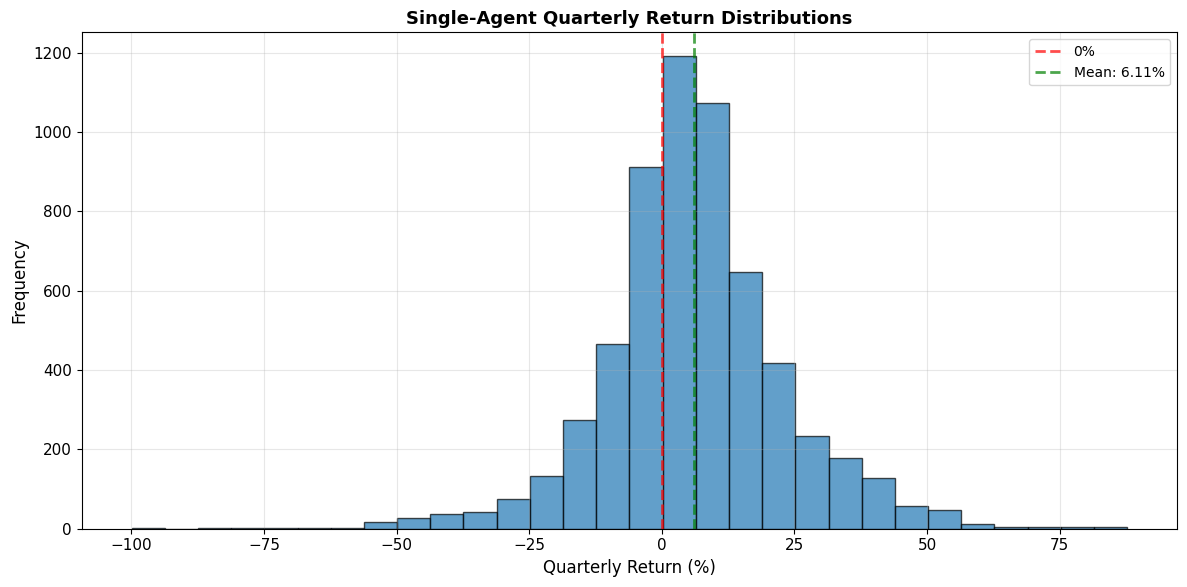

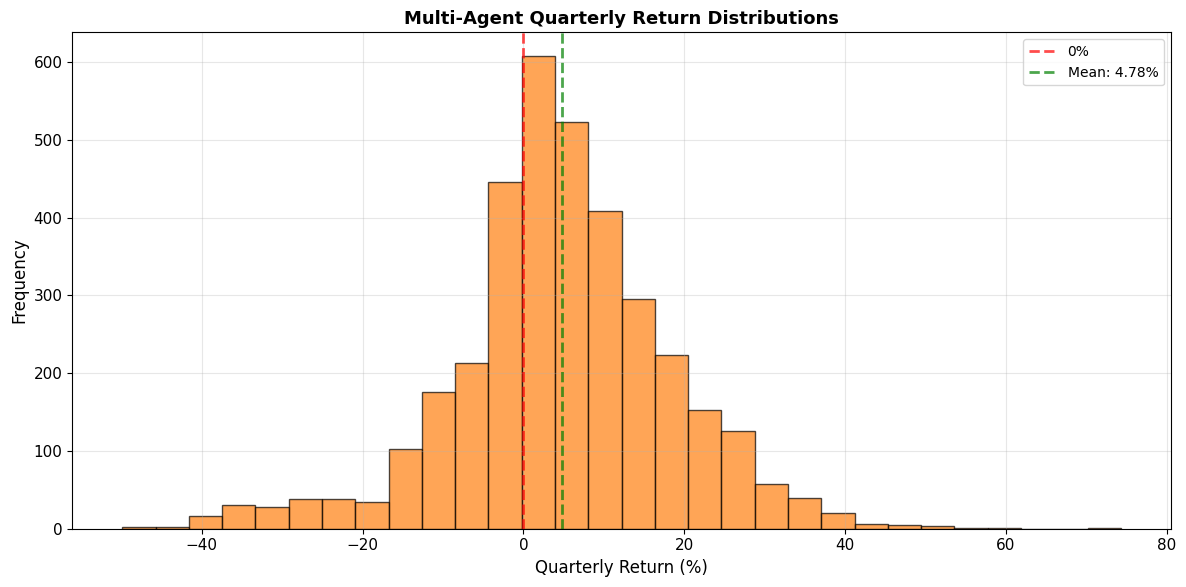

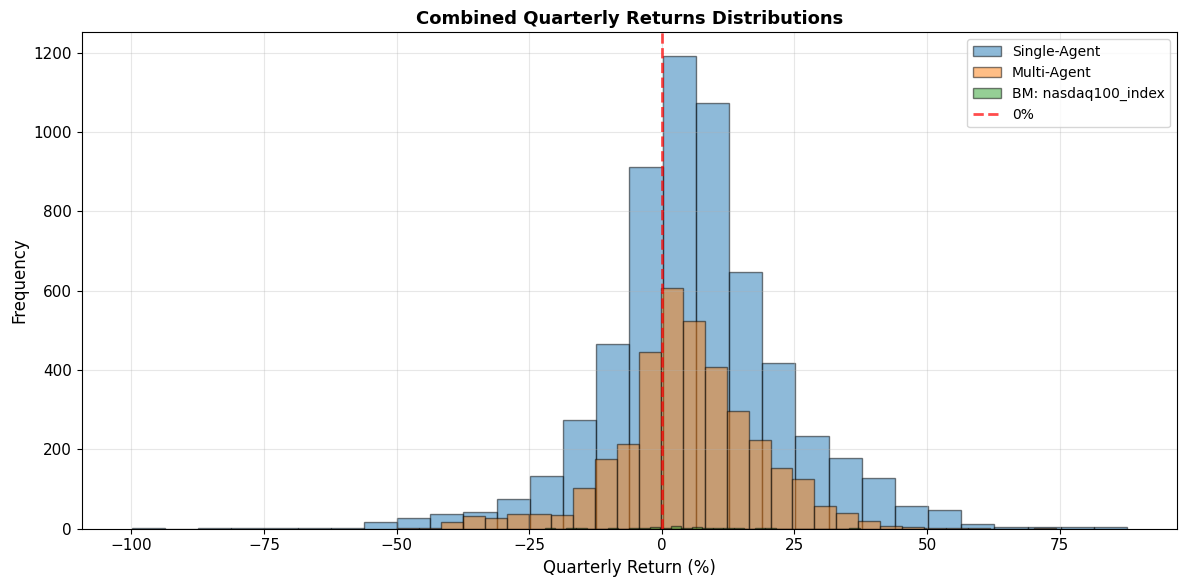

In [184]:
# ── Quarterly return distributions for both datasets ───────────────────────
plot_return_distributions(
    [all_nav_series_single, all_nav_series_multi],
    ["Single-Agent Quarterly Return Distributions", "Multi-Agent Quarterly Return Distributions"],
    benchmarks_dict=benchmarks
)


## 7. Risk-Return Scatter + Bar Charts

In [185]:
def plot_risk_return(df_metrics_list, agent_col_names, titles):
    """Plot risk-return scatter and bar charts for all datasets."""
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # ── Row 1: Single-Agent ──
    df_data = df_metrics_list[0] if len(df_metrics_list) > 0 else None
    agent_col = agent_col_names[0] if len(agent_col_names) > 0 else None
    
    if df_data is not None:
        # Scatter
        ax = fig.add_subplot(gs[0, 0])
        for i, agent in enumerate(sorted(df_data[agent_col].unique())):
            agent_data = df_data[df_data[agent_col] == agent]
            ax.scatter(agent_data["volatility_pct"], agent_data["cagr_pct"], 
                      alpha=0.6, s=80, color=colors[i % len(colors)], label=agent)
        ax.set_xlabel("Volatility (%)")
        ax.set_ylabel("CAGR (%)")
        ax.set_title(f"{titles[0]} — Risk-Return Scatter")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Sharpe bars
        ax = fig.add_subplot(gs[0, 1])
        sharpe_by_agent = df_data.groupby(agent_col)["sharpe"].mean().sort_values(ascending=False)
        bars = ax.bar(range(len(sharpe_by_agent)), sharpe_by_agent.values, color=colors[:len(sharpe_by_agent)])
        ax.set_xticks(range(len(sharpe_by_agent)))
        ax.set_xticklabels(sharpe_by_agent.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("Sharpe Ratio")
        ax.set_title(f"{titles[0]} — Sharpe")
        ax.grid(True, alpha=0.3, axis='y')
        
        # Max DD bars
        ax = fig.add_subplot(gs[0, 2])
        dd_by_agent = df_data.groupby(agent_col)["max_drawdown_pct"].mean().sort_values()
        bars = ax.bar(range(len(dd_by_agent)), dd_by_agent.values, color=colors[:len(dd_by_agent)])
        ax.set_xticks(range(len(dd_by_agent)))
        ax.set_xticklabels(dd_by_agent.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("Max Drawdown (%)")
        ax.set_title(f"{titles[0]} — Max DD")
        ax.grid(True, alpha=0.3, axis='y')
    
    # ── Row 2: Multi-Agent ──
    df_data = df_metrics_list[1] if len(df_metrics_list) > 1 else None
    agent_col = agent_col_names[1] if len(agent_col_names) > 1 else None
    
    if df_data is not None:
        # Scatter
        ax = fig.add_subplot(gs[1, 0])
        for i, agent in enumerate(sorted(df_data[agent_col].unique())):
            agent_data = df_data[df_data[agent_col] == agent]
            ax.scatter(agent_data["volatility_pct"], agent_data["cagr_pct"],
                      alpha=0.6, s=80, color=colors[i % len(colors)], label=agent)
        ax.set_xlabel("Volatility (%)")
        ax.set_ylabel("CAGR (%)")
        ax.set_title(f"{titles[1]} — Risk-Return Scatter")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Sharpe bars
        ax = fig.add_subplot(gs[1, 1])
        sharpe_by_agent = df_data.groupby(agent_col)["sharpe"].mean().sort_values(ascending=False)
        bars = ax.bar(range(len(sharpe_by_agent)), sharpe_by_agent.values, color=colors[:len(sharpe_by_agent)])
        ax.set_xticks(range(len(sharpe_by_agent)))
        ax.set_xticklabels(sharpe_by_agent.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("Sharpe Ratio")
        ax.set_title(f"{titles[1]} — Sharpe")
        ax.grid(True, alpha=0.3, axis='y')
        
        # Max DD bars
        ax = fig.add_subplot(gs[1, 2])
        dd_by_agent = df_data.groupby(agent_col)["max_drawdown_pct"].mean().sort_values()
        bars = ax.bar(range(len(dd_by_agent)), dd_by_agent.values, color=colors[:len(dd_by_agent)])
        ax.set_xticks(range(len(dd_by_agent)))
        ax.set_xticklabels(dd_by_agent.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("Max Drawdown (%)")
        ax.set_title(f"{titles[1]} — Max DD")
        ax.grid(True, alpha=0.3, axis='y')
    
    # ── Row 3: Combined Comparison ──
    ax = fig.add_subplot(gs[2, 0])
    ax.set_title("Combined Comparison — Risk-Return")
    ax.set_xlabel("Volatility (%)")
    ax.set_ylabel("CAGR (%)")
    ax.grid(True, alpha=0.3)
    
    # Collect combined metrics
    combined_metrics = []
    if len(df_metrics_list) > 0:
        sa_mean_vol = df_metrics_list[0]["volatility_pct"].mean()
        sa_mean_cagr = df_metrics_list[0]["cagr_pct"].mean()
        ax.scatter([sa_mean_vol], [sa_mean_cagr], s=200, color=colors[0], marker='o', label="Single-Agent Mean")
    
    if len(df_metrics_list) > 1:
        ma_mean_vol = df_metrics_list[1]["volatility_pct"].mean()
        ma_mean_cagr = df_metrics_list[1]["cagr_pct"].mean()
        ax.scatter([ma_mean_vol], [ma_mean_cagr], s=200, color=colors[1], marker='s', label="Multi-Agent Mean")
    
    ax.legend()
    
    # Combined Sharpe bars
    ax = fig.add_subplot(gs[2, 1])
    sharpe_data = []
    sharpe_labels = []
    if len(df_metrics_list) > 0:
        sharpe_data.append(df_metrics_list[0]["sharpe"].mean())
        sharpe_labels.append("SA Mean")
    if len(df_metrics_list) > 1:
        sharpe_data.append(df_metrics_list[1]["sharpe"].mean())
        sharpe_labels.append("MA Mean")
    
    if sharpe_data:
        bars = ax.bar(range(len(sharpe_data)), sharpe_data, color=colors[:len(sharpe_data)])
        ax.set_xticks(range(len(sharpe_data)))
        ax.set_xticklabels(sharpe_labels)
        ax.set_ylabel("Sharpe Ratio")
        ax.set_title("Combined Comparison — Sharpe")
        ax.grid(True, alpha=0.3, axis='y')
    
    # Combined Max DD bars
    ax = fig.add_subplot(gs[2, 2])
    dd_data = []
    dd_labels = []
    if len(df_metrics_list) > 0:
        dd_data.append(df_metrics_list[0]["max_drawdown_pct"].mean())
        dd_labels.append("SA Mean")
    if len(df_metrics_list) > 1:
        dd_data.append(df_metrics_list[1]["max_drawdown_pct"].mean())
        dd_labels.append("MA Mean")
    
    if dd_data:
        bars = ax.bar(range(len(dd_data)), dd_data, color=colors[:len(dd_data)])
        ax.set_xticks(range(len(dd_data)))
        ax.set_xticklabels(dd_labels)
        ax.set_ylabel("Max Drawdown (%)")
        ax.set_title("Combined Comparison — Max DD")
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.show()

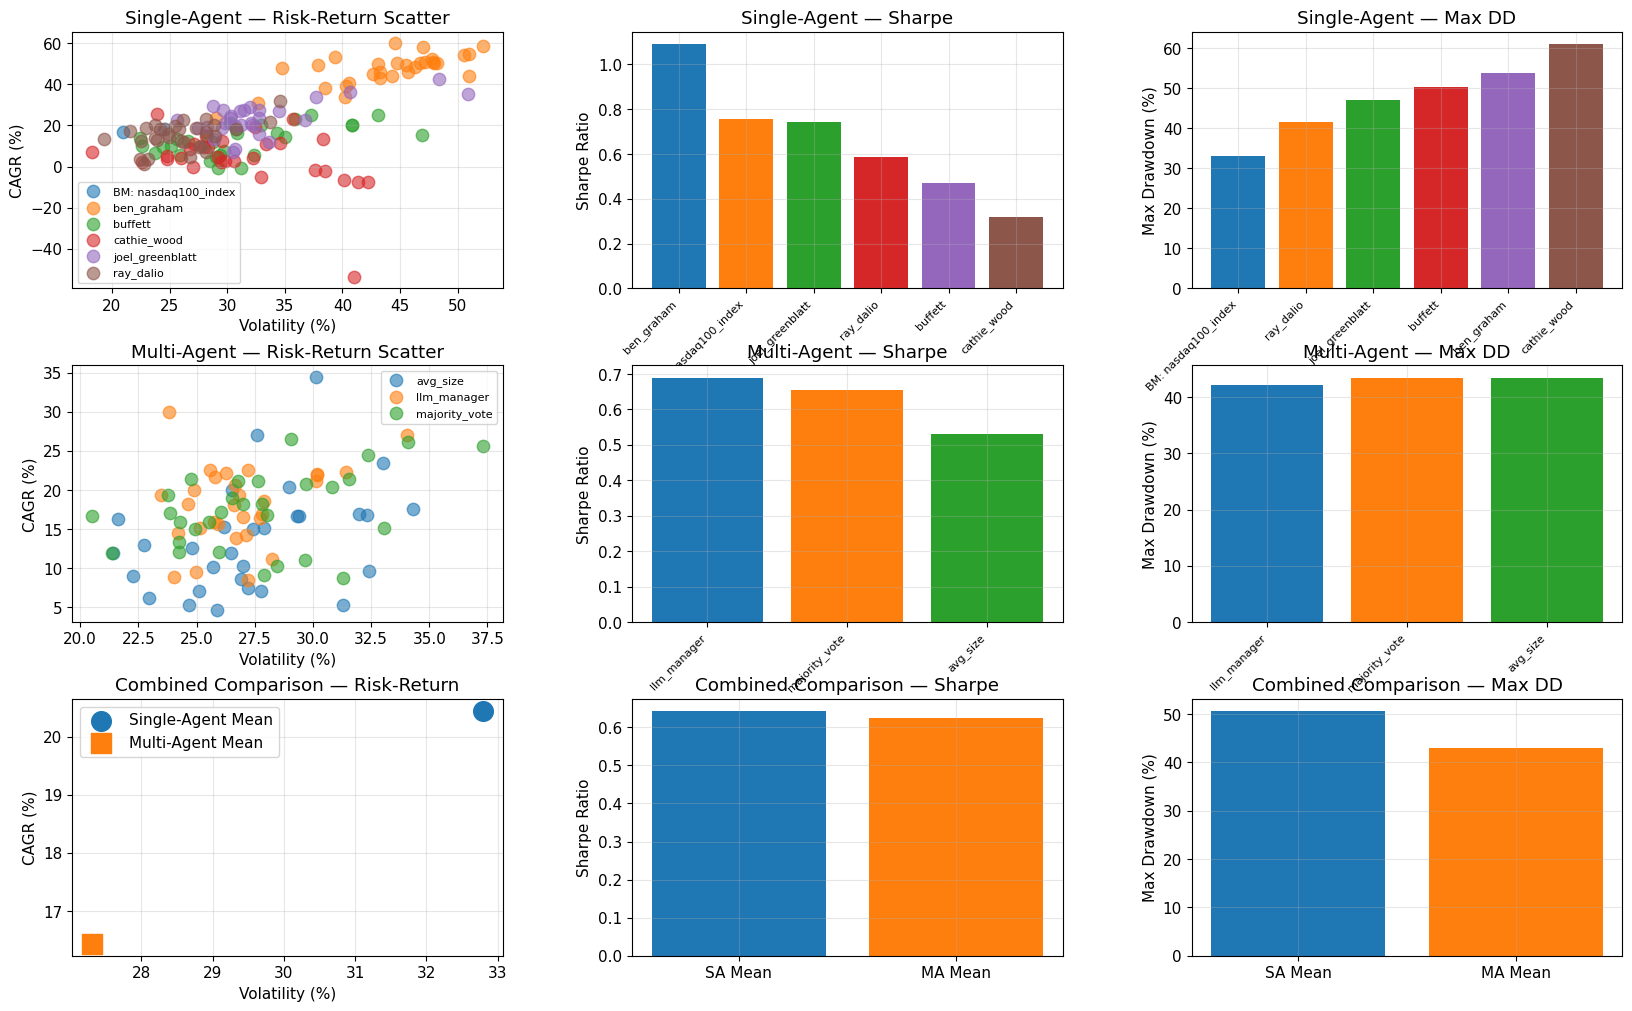

In [186]:
# ── Risk-Return scatter and bar charts for both datasets ────────────────────
# Need to include benchmarks in single-agent metrics for fair comparison
df_metrics_single_with_bm = df_metrics_single.copy()
for bm_name, bm_series in benchmarks.items():
    bm_navs = np.array(list(bm_series.values()))
    bm_metrics = compute_metrics(bm_navs)
    bm_row = {
        "agent": f"BM: {bm_name}",
        "run": 1,
        "file": "(benchmarks.json)",
        **bm_metrics
    }
    df_metrics_single_with_bm = pd.concat([df_metrics_single_with_bm, pd.DataFrame([bm_row])], ignore_index=True)

plot_risk_return(
    [df_metrics_single_with_bm, df_metrics_multi],
    ["agent", "strategy"],
    ["Single-Agent", "Multi-Agent"]
)

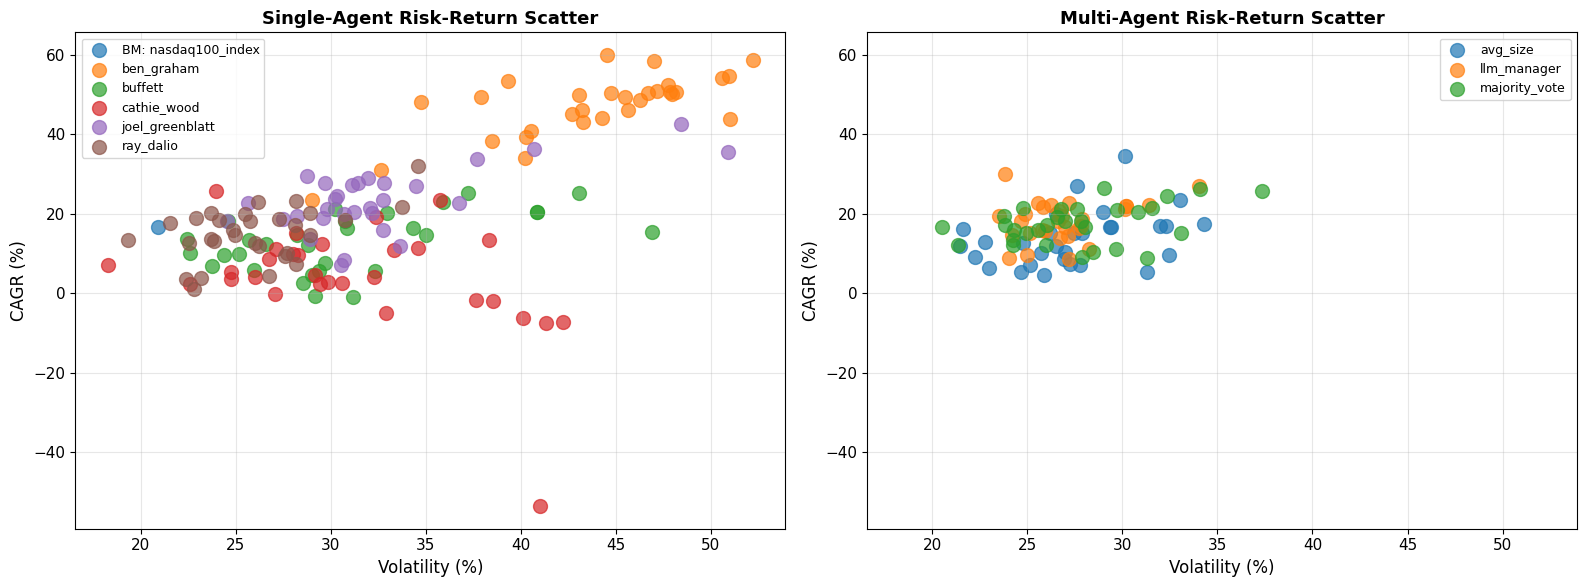

In [187]:
# ── Single and Multi-Agent Risk-Return Scatter (Side by Side) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate shared axis limits across both datasets
vol_min = min(df_metrics_single_with_bm["volatility_pct"].min(), df_metrics_multi["volatility_pct"].min())
vol_max = max(df_metrics_single_with_bm["volatility_pct"].max(), df_metrics_multi["volatility_pct"].max())
cagr_min = min(df_metrics_single_with_bm["cagr_pct"].min(), df_metrics_multi["cagr_pct"].min())
cagr_max = max(df_metrics_single_with_bm["cagr_pct"].max(), df_metrics_multi["cagr_pct"].max())

# Add padding to axis limits (5% buffer)
vol_pad = (vol_max - vol_min) * 0.05
cagr_pad = (cagr_max - cagr_min) * 0.05

# Left: Single-Agent Risk-Return
ax = axes[0]
for i, agent in enumerate(sorted(df_metrics_single_with_bm["agent"].unique())):
    agent_data = df_metrics_single_with_bm[df_metrics_single_with_bm["agent"] == agent]
    ax.scatter(agent_data["volatility_pct"], agent_data["cagr_pct"], 
              alpha=0.7, s=100, color=colors[i % len(colors)], label=agent)
ax.set_xlabel("Volatility (%)", fontsize=12)
ax.set_ylabel("CAGR (%)", fontsize=12)
ax.set_title("Single-Agent Risk-Return Scatter", fontsize=13, fontweight='bold')
ax.set_xlim(vol_min - vol_pad, vol_max + vol_pad)
ax.set_ylim(cagr_min - cagr_pad, cagr_max + cagr_pad)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

# Right: Multi-Agent Risk-Return
ax = axes[1]
for i, strategy in enumerate(sorted(df_metrics_multi["strategy"].unique())):
    strategy_data = df_metrics_multi[df_metrics_multi["strategy"] == strategy]
    ax.scatter(strategy_data["volatility_pct"], strategy_data["cagr_pct"], 
              alpha=0.7, s=100, color=colors[i % len(colors)], label=strategy)
ax.set_xlabel("Volatility (%)", fontsize=12)
ax.set_ylabel("CAGR (%)", fontsize=12)
ax.set_title("Multi-Agent Risk-Return Scatter", fontsize=13, fontweight='bold')
ax.set_xlim(vol_min - vol_pad, vol_max + vol_pad)
ax.set_ylim(cagr_min - cagr_pad, cagr_max + cagr_pad)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

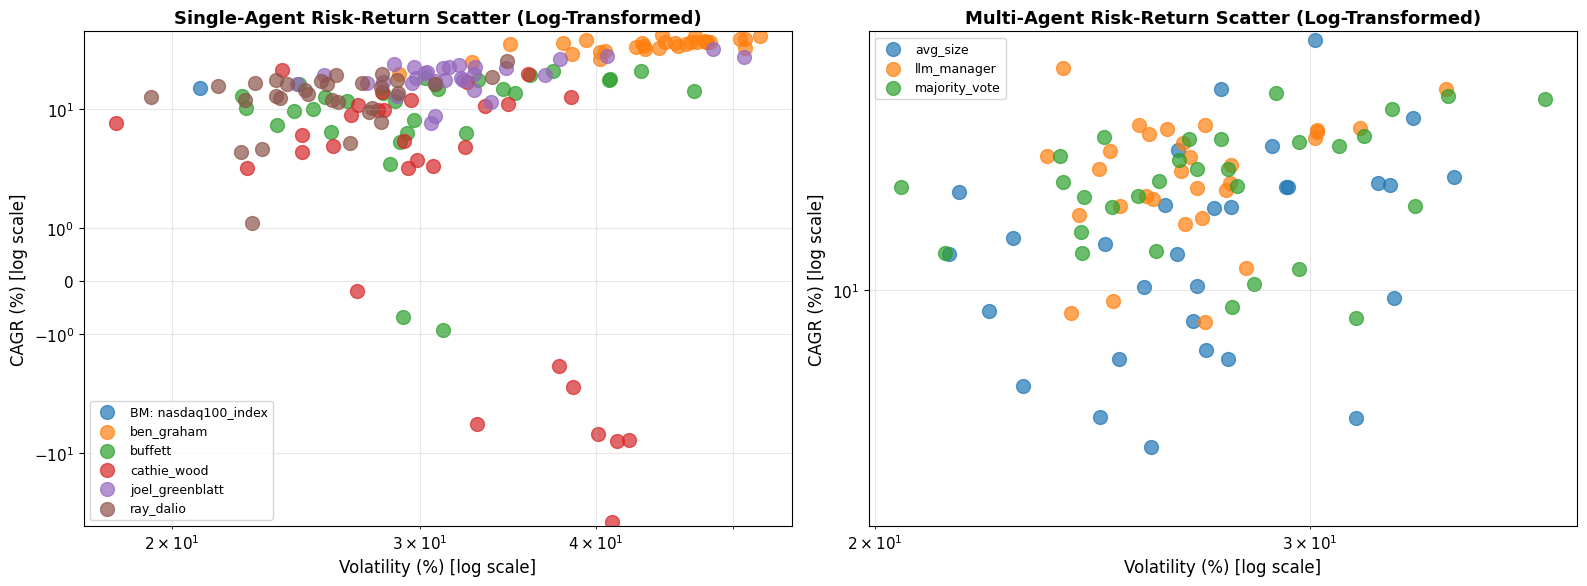

In [188]:
# ── Single and Multi-Agent Risk-Return Scatter (Log-Transformed) ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate shared axis limits across both datasets
vol_min = min(df_metrics_single_with_bm["volatility_pct"].min(), df_metrics_multi["volatility_pct"].min())
vol_max = max(df_metrics_single_with_bm["volatility_pct"].max(), df_metrics_multi["volatility_pct"].max())
cagr_min = min(df_metrics_single_with_bm["cagr_pct"].min(), df_metrics_multi["cagr_pct"].min())
cagr_max = max(df_metrics_single_with_bm["cagr_pct"].max(), df_metrics_multi["cagr_pct"].max())

# Left: Single-Agent Risk-Return (Log-Transformed)
ax = axes[0]
for i, agent in enumerate(sorted(df_metrics_single_with_bm["agent"].unique())):
    agent_data = df_metrics_single_with_bm[df_metrics_single_with_bm["agent"] == agent]
    ax.scatter(agent_data["volatility_pct"], agent_data["cagr_pct"], 
              alpha=0.7, s=100, color=colors[i % len(colors)], label=agent)
ax.set_xlabel("Volatility (%) [log scale]", fontsize=12)
ax.set_ylabel("CAGR (%) [log scale]", fontsize=12)
ax.set_title("Single-Agent Risk-Return Scatter (Log-Transformed)", fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('symlog')  # Use symlog for CAGR to handle potential negative values
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Right: Multi-Agent Risk-Return (Log-Transformed)
ax = axes[1]
for i, strategy in enumerate(sorted(df_metrics_multi["strategy"].unique())):
    strategy_data = df_metrics_multi[df_metrics_multi["strategy"] == strategy]
    ax.scatter(strategy_data["volatility_pct"], strategy_data["cagr_pct"], 
              alpha=0.7, s=100, color=colors[i % len(colors)], label=strategy)
ax.set_xlabel("Volatility (%) [log scale]", fontsize=12)
ax.set_ylabel("CAGR (%) [log scale]", fontsize=12)
ax.set_title("Multi-Agent Risk-Return Scatter (Log-Transformed)", fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('symlog')  # Use symlog for CAGR to handle potential negative values
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

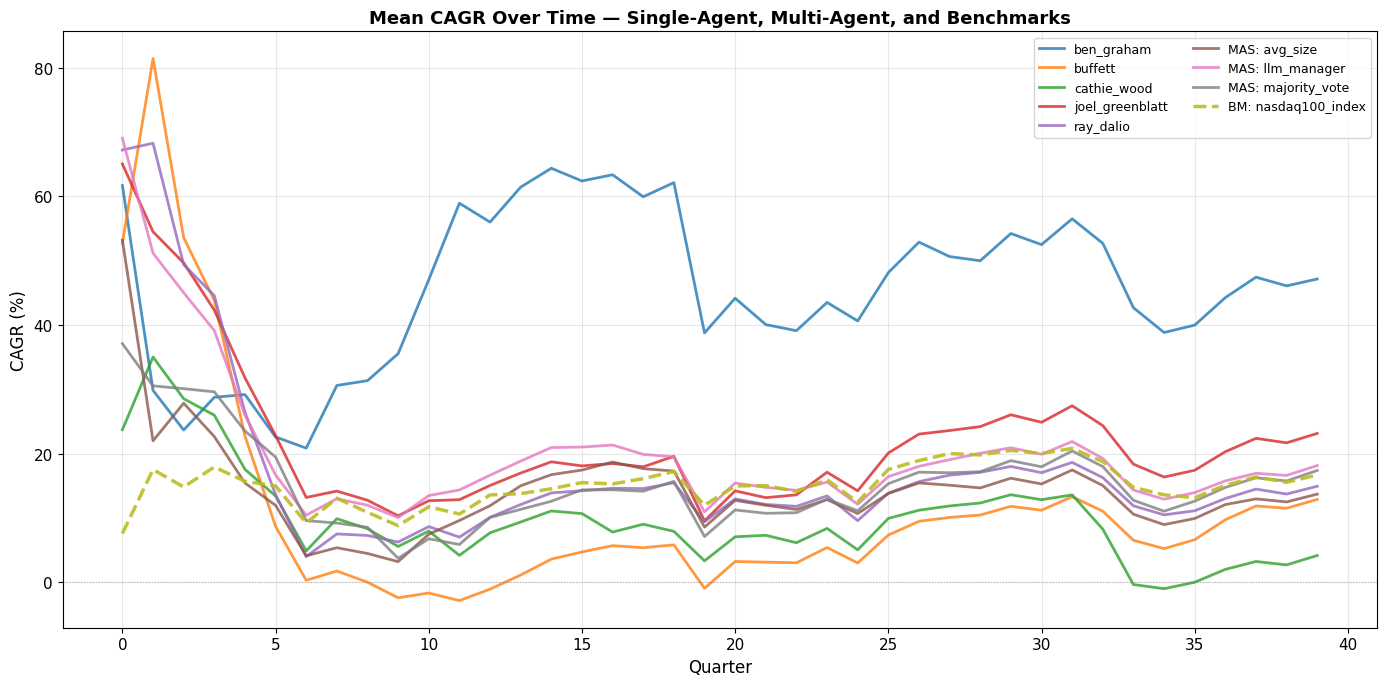

In [189]:
# ── Mean CAGR Over Time ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Function to compute CAGR at each time point
def compute_cagr_over_time(navs, ppy=PERIODS_PER_YEAR):
    """Compute CAGR at each time point (quarter)."""
    cagr_series = []
    for t in range(1, len(navs)):
        returns = quarterly_returns(navs[:t+1])
        n_periods = len(returns)
        if n_periods > 0:
            cum_return = np.prod(1 + returns) - 1
            cagr = (cum_return + 1) ** (ppy / n_periods) - 1
            cagr_series.append(cagr * 100)
        else:
            cagr_series.append(0)
    return cagr_series

# ── Single-Agent Mean CAGR ──
single_agent_cagr_over_time = {}
for agent_name, runs_dict in all_nav_series_single.items():
    cagr_curves = []
    for run_idx, (periods, navs) in runs_dict.items():
        cagr_curves.append(compute_cagr_over_time(navs))
    if cagr_curves:
        mean_cagr = np.mean(cagr_curves, axis=0)
        single_agent_cagr_over_time[agent_name] = mean_cagr

# ── Multi-Agent Mean CAGR ──
multi_agent_cagr_over_time = {}
for strategy_name, runs_dict in all_nav_series_multi.items():
    cagr_curves = []
    for run_idx, (periods, navs) in runs_dict.items():
        cagr_curves.append(compute_cagr_over_time(navs))
    if cagr_curves:
        mean_cagr = np.mean(cagr_curves, axis=0)
        multi_agent_cagr_over_time[strategy_name] = mean_cagr

# ── Benchmark Mean CAGR ──
benchmark_cagr_over_time = {}
for bm_name, bm_series in benchmarks.items():
    bm_navs = np.array(list(bm_series.values()))
    cagr_curve = compute_cagr_over_time(bm_navs)
    benchmark_cagr_over_time[f"BM: {bm_name}"] = cagr_curve

# ── Plot Single-Agent CAGR curves ──
for i, (agent_name, cagr_curve) in enumerate(sorted(single_agent_cagr_over_time.items())):
    ax.plot(range(len(cagr_curve)), cagr_curve, "-", lw=2, 
            color=colors[i % len(colors)], label=f"{agent_name}", alpha=0.8)

# ── Plot Multi-Agent CAGR curves ──
for i, (strategy_name, cagr_curve) in enumerate(sorted(multi_agent_cagr_over_time.items())):
    ax.plot(range(len(cagr_curve)), cagr_curve, "-", lw=2,
            color=colors[(i + len(single_agent_cagr_over_time)) % len(colors)], 
            label=f"MAS: {strategy_name}", alpha=0.8)

# ── Plot Benchmark CAGR curves ──
for i, (bm_name, cagr_curve) in enumerate(sorted(benchmark_cagr_over_time.items())):
    ax.plot(range(len(cagr_curve)), cagr_curve, "--", lw=2.5,
            color=colors[(i + len(single_agent_cagr_over_time) + len(multi_agent_cagr_over_time)) % len(colors)],
            label=bm_name, alpha=0.9)

ax.set_xlabel("Quarter", fontsize=12)
ax.set_ylabel("CAGR (%)", fontsize=12)
ax.set_title("Mean CAGR Over Time — Single-Agent, Multi-Agent, and Benchmarks", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", ls=":", lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# 8. Portfolio Composition

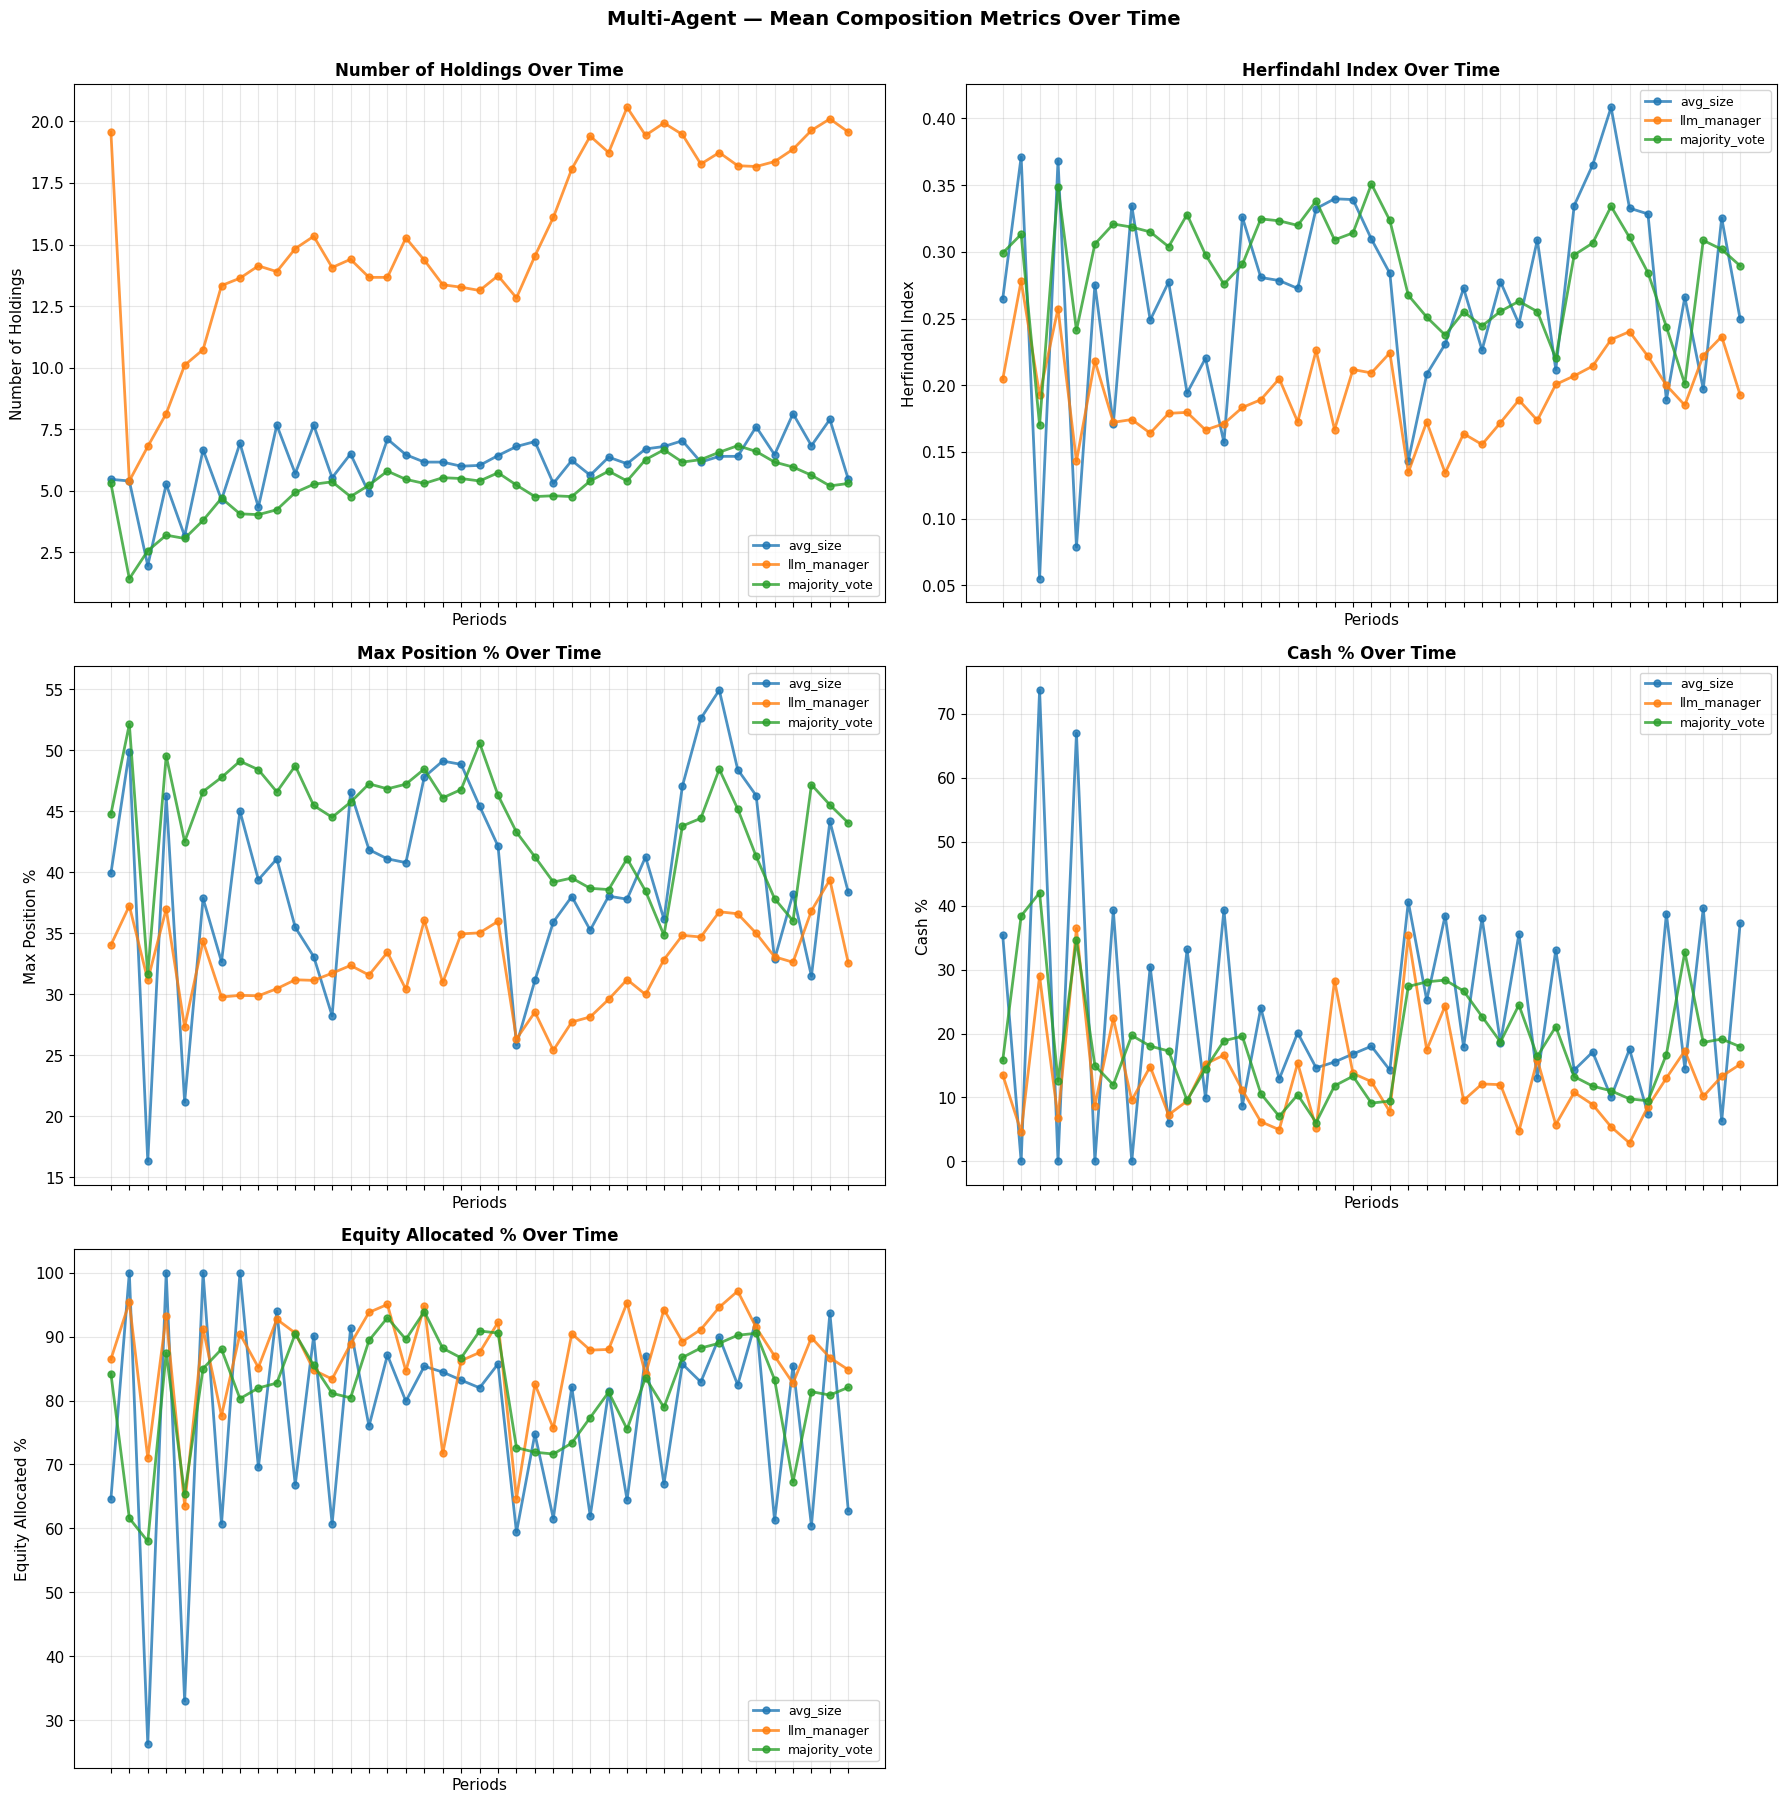

In [190]:
# ── Mean Composition Metrics Over Time ──────────────────────────────────────
def plot_composition_metrics_over_time(df_composition, title="", agent_col_name="strategy"):
    """Plot mean composition metrics over time per strategy."""
    metrics = ["num_holdings", "herfindahl_index", "max_position_pct", "cash_pct", "equity_allocated_pct"]
    metric_labels = ["Number of Holdings", "Herfindahl Index", "Max Position %", "Cash %", "Equity Allocated %"]
    
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    axes = axes.flatten()
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        # Group by strategy and period, compute mean
        grouped = df_composition.groupby([agent_col_name, "period"])[metric].mean().reset_index()
        
        # Plot each strategy
        for strategy in sorted(grouped[agent_col_name].unique()):
            strategy_data = grouped[grouped[agent_col_name] == strategy]
            ax.plot(strategy_data["period"], strategy_data[metric], 
                   marker="o", label=strategy, linewidth=2, markersize=5, alpha=0.8)
        
        ax.set_xlabel("Periods", fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f"{label} Over Time", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", labelbottom=False)
    
    # Hide the last unused subplot
    axes[-1].axis("off")
    
    plt.suptitle(f"{title} — Mean Composition Metrics Over Time", fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()

# Plot multi-agent composition metrics
plot_composition_metrics_over_time(df_composition_multi, "Multi-Agent")

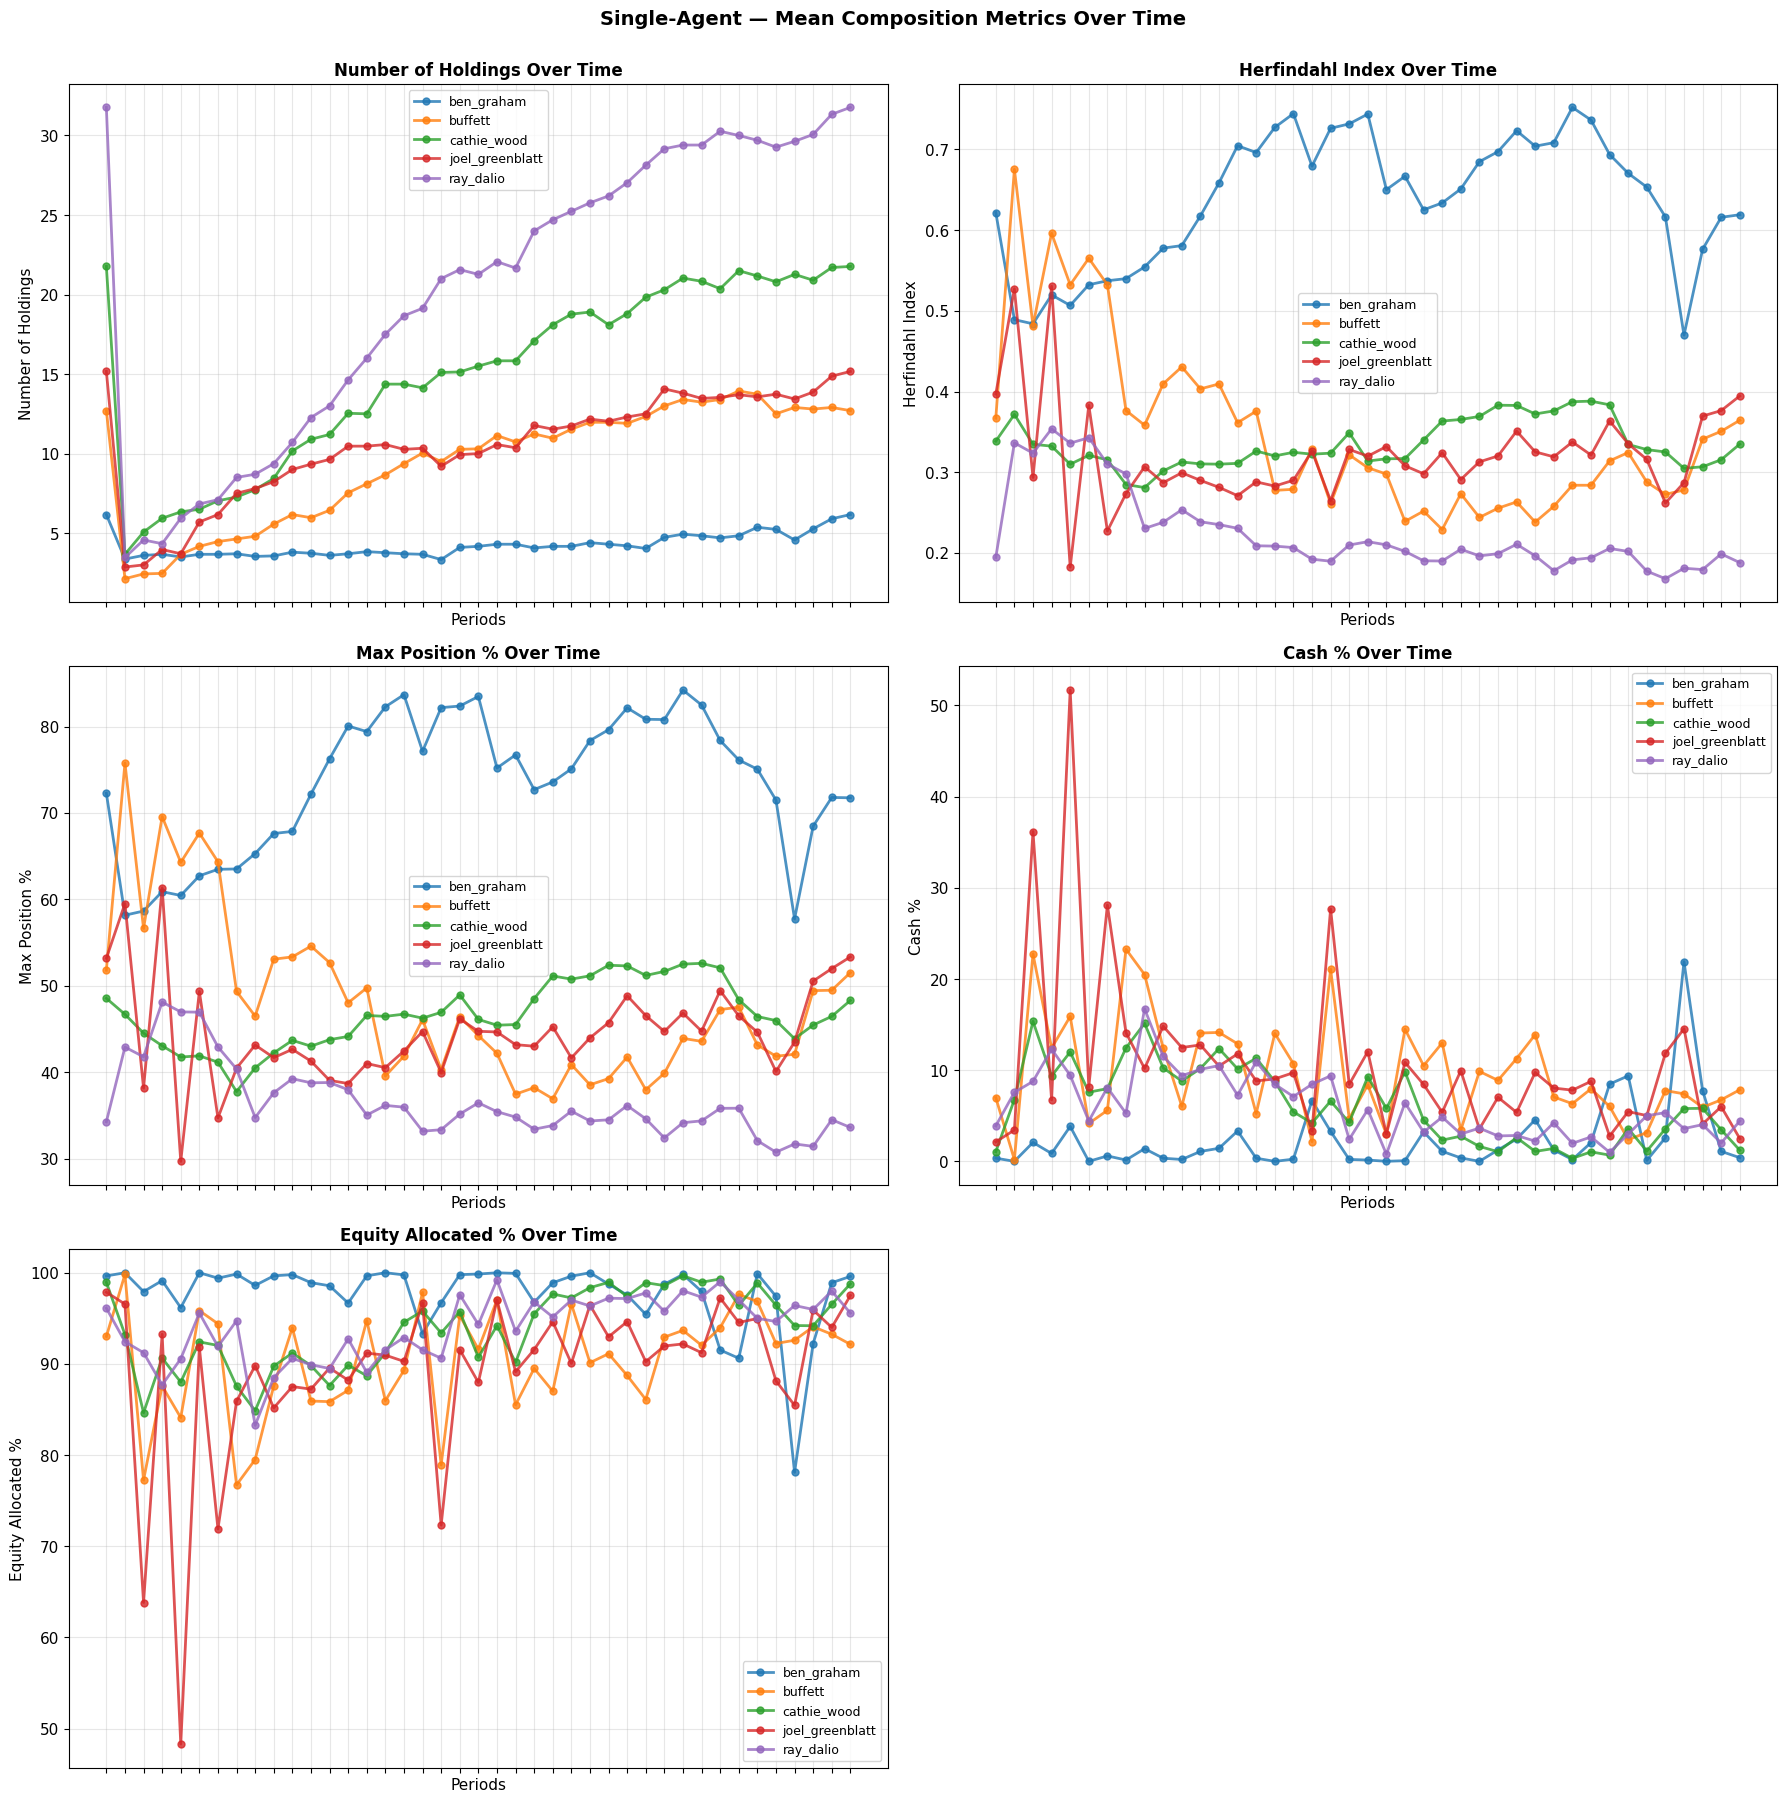

In [191]:
plot_composition_metrics_over_time(df_composition_single, "Single-Agent", agent_col_name="agent")

# 03 Summary Tables LaTeX

In [193]:
# ── Generate LaTeX summary tables for both datasets ──────────────────────────
def format_agent_name(name):
    """Convert snake_case or benchmark format to Title Case."""
    if name.startswith("BM:"):
        # Benchmark names like "BM: cap_weighted" -> "Cap Weighted"
        bm_part = name.replace("BM: ", "").replace("_", " ").title()
        return f"\\textbf{{{bm_part}}}"
    else:
        # Agent names like "ben_graham" -> "Ben Graham"
        return name.replace("_", " ").title()

metrics_to_report = ["total_return_pct", "cagr_pct", "volatility_pct", "sharpe", "sortino", "max_drawdown_pct"]

# Prepare combined data: single-agent + benchmarks
df_single_agg = df_metrics_single.copy()
for bm_name, bm_series in benchmarks.items():
    bm_navs = np.array(list(bm_series.values()))
    bm_metrics = compute_metrics(bm_navs)
    bm_row = {
        "agent": f"BM: {bm_name}",
        "run": 1,
        **{k: v for k, v in bm_metrics.items() if k in metrics_to_report}
    }
    df_single_agg = pd.concat([df_single_agg, pd.DataFrame([bm_row])], ignore_index=True)

df_single_agg = df_single_agg.groupby("agent")[metrics_to_report].agg(['mean', 'std']).round(2)

# Prepare multi-agent data
df_multi_agg = df_metrics_multi.groupby("strategy")[metrics_to_report].agg(['mean', 'std']).round(2)

# Combine both dataframes
df_combined = pd.concat([df_single_agg, df_multi_agg], axis=0, keys=['Single-Agent', 'Multi-Agent'])
df_combined = df_combined.droplevel(0)  # Remove the key level to flatten

# Sort by CAGR descending
cagr_values = df_combined[('cagr_pct', 'mean')].values
sorted_indices = np.argsort(-cagr_values)
df_combined_sorted = df_combined.iloc[sorted_indices]

# Format as "mean ± std"
formatted_data = []
for agent_name in df_combined_sorted.index:
    row = {"Agent": format_agent_name(agent_name)}
    row["Total Return (%)"] = f"${df_combined_sorted.loc[agent_name, ('total_return_pct', 'mean')]:.2f} \\pm {df_combined_sorted.loc[agent_name, ('total_return_pct', 'std')]:.2f}$"
    row["CAGR (%)"] = f"${df_combined_sorted.loc[agent_name, ('cagr_pct', 'mean')]:.2f} \\pm {df_combined_sorted.loc[agent_name, ('cagr_pct', 'std')]:.2f}$"
    row["Volatility (%)"] = f"${df_combined_sorted.loc[agent_name, ('volatility_pct', 'mean')]:.2f} \\pm {df_combined_sorted.loc[agent_name, ('volatility_pct', 'std')]:.2f}$"
    row["Sharpe Ratio"] = f"${df_combined_sorted.loc[agent_name, ('sharpe', 'mean')]:.3f} \\pm {df_combined_sorted.loc[agent_name, ('sharpe', 'std')]:.3f}$"
    row["Sortino Ratio"] = f"${df_combined_sorted.loc[agent_name, ('sortino', 'mean')]:.3f} \\pm {df_combined_sorted.loc[agent_name, ('sortino', 'std')]:.3f}$"
    row["Max DD (%)"] = f"${df_combined_sorted.loc[agent_name, ('max_drawdown_pct', 'mean')]:.2f} \\pm {df_combined_sorted.loc[agent_name, ('max_drawdown_pct', 'std')]:.2f}$"
    formatted_data.append(row)

# Print LaTeX Table 1: CAGR, Volatility, Sharpe
print(f"\\begin{{table}}[h]")
print(f"\\centering")
print(f"\\begin{{tabular}}{{lccc}}")
print(f"\\toprule")
print(f"Agent & CAGR (\\%) & Volatility (\\%) & Sharpe Ratio \\\\")
print(f"\\midrule")

for row in formatted_data:
    agent = row["Agent"]
    cagr = row["CAGR (%)"]
    vol = row["Volatility (%)"]
    sharpe = row["Sharpe Ratio"]
    print(f"{agent} & {cagr} & {vol} & {sharpe} \\\\")

print(f"\\bottomrule")
print(f"\\end{{tabular}}")
print(f"\\caption{{Performance metrics for single-agent, multi-agent, and benchmark portfolios. Values are mean $\\pm$ std across runs.}}")
print(f"\\label{{table:combined_returns}}")
print(f"\\end{{table}}")
print()

# Print LaTeX Table 2: Total Return, Sortino, Max DD
print(f"\\begin{{table}}[h]")
print(f"\\centering")
print(f"\\begin{{tabular}}{{lccc}}")
print(f"\\toprule")
print(f"Agent & Total Return (\\%) & Sortino Ratio & Max DD (\\%) \\\\")
print(f"\\midrule")

for row in formatted_data:
    agent = row["Agent"]
    total_ret = row["Total Return (%)"]
    sortino = row["Sortino Ratio"]
    maxdd = row["Max DD (%)"]
    print(f"{agent} & {total_ret} & {sortino} & {maxdd} \\\\")

print(f"\\bottomrule")
print(f"\\end{{tabular}}")
print(f"\\caption{{Cumulative return and downside metrics for all strategies. Values are mean $\\pm$ std across runs.}}")
print(f"\\label{{table:combined_downside}}")
print(f"\\end{{table}}")
print()

\begin{table}[h]
\centering
\begin{tabular}{lccc}
\toprule
Agent & CAGR (\%) & Volatility (\%) & Sharpe Ratio \\
\midrule
Ben Graham & $47.17 \pm 8.10$ & $43.79 \pm 5.51$ & $1.091 \pm 0.110$ \\
Joel Greenblatt & $23.16 \pm 7.95$ & $32.54 \pm 5.69$ & $0.744 \pm 0.170$ \\
Llm Manager & $18.16 \pm 5.01$ & $26.91 \pm 2.40$ & $0.690 \pm 0.160$ \\
Majority Vote & $17.40 \pm 4.96$ & $27.62 \pm 3.80$ & $0.655 \pm 0.140$ \\
\textbf{Nasdaq100 Index} & $16.70 \pm nan$ & $20.94 \pm nan$ & $0.755 \pm nan$ \\
Ray Dalio & $14.95 \pm 6.75$ & $26.01 \pm 3.39$ & $0.585 \pm 0.220$ \\
Avg Size & $13.73 \pm 6.83$ & $27.38 \pm 3.46$ & $0.531 \pm 0.200$ \\
Buffett & $12.90 \pm 7.28$ & $30.89 \pm 6.18$ & $0.470 \pm 0.200$ \\
Cathie Wood & $4.18 \pm 13.73$ & $31.17 \pm 6.12$ & $0.317 \pm 0.220$ \\
\bottomrule
\end{tabular}
\caption{Performance metrics for single-agent, multi-agent, and benchmark portfolios. Values are mean $\pm$ std across runs.}
\label{table:combined_returns}
\end{table}

\begin{table}[h]
\ce